# DXA: тестирование и подбор параметров для семи QC-алгоритмов

Ноутбук предназначен для разработки интерпретируемых алгоритмов контроля качества
денситометрических изображений. Он извлекает признаки, визуализирует найденную геометрию,
перебирает параметры по разметке и сохраняет лучшие конфигурации.

Проверяются семь концептуальных задач:

1. корректная укладка позвоночника: половина Th12 и верхние края подвздошных костей;
2. ось позвоночника;
3. посторонние предметы, выраженные артефакты и наложения;
4. сколиоз по углу первой и последней локальной оси;
5. позиционирование и ротация бедра;
6. корректность области интересов бедра: 3 см сверху, 3 см снизу, 2 см латерально;
7. металл в снимке.

Это исследовательский стенд. Порог, найденный на текущих данных, нельзя считать клинически
валидированным без независимой выборки и экспертного просмотра ошибок.


## Где находятся таргеты

| Алгоритм | Источник таргета | Поле |
|---|---|---|
| 1. Укладка позвоночника | `разметка.xlsx` | `Позвоночник / корректная укладка` |
| 2. Ось позвоночника | `разметка.xlsx` | `Позвоночник / правильно выравнена ось` |
| 3. Артефакты | `разметка.xlsx` | `Позвоночник / посторонние предметы...` |
| 4. Сколиоз | комментарий в `разметка.xlsx` | наличие слова `сколиоз` |
| 5. Позиционирование/ротация | `разметка.xlsx` | отдельные поля для правого и левого бедра |
| 6. Область интересов | `разметка.xlsx` | отдельные поля для правого и левого бедра |
| 7. Металл | `labels.csv` | `metal` |

В Excel семь бинарных QC-полей: три для позвоночника и по два для каждой стороны бедра.
Сколиоз и металл не являются двумя дополнительными бинарными столбцами Excel, поэтому
оцениваются по другим источникам. По текущей разметке металл надёжно размечен только для
снимков бедра; результат metal-head на позвоночнике считается экспериментальным.


## Запуск

1. Скопируйте notebook в `C:\Users\Андрей\Desktop\Хакатон` рядом с
   `dxa_inference_pipeline.py`.
2. Выберите kernel `ml_env_py311`.
3. Проверьте `PROJECT_ROOT` в следующей ячейке.
4. Выполните **Run All**.

Нужны пакеты из основного прототипа: `numpy`, `pandas`, `matplotlib`, `scipy`,
`scikit-learn`, `pydicom`, `torch`, `torchvision`, `Pillow`, `tqdm`.
Для SAM дополнительно нужен `segment-anything` и checkpoint `sam_vit_b_01ec64.pth`.

Признаки кэшируются в `prototype_output/target_tuning`. Чтобы пересчитать их после
изменения алгоритма, установите `FORCE_RECOMPUTE = True`.


In [1]:
from pathlib import Path, PurePosixPath
from itertools import product
import importlib.util
import json
import math
import re
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
from IPython.display import display
from PIL import Image
from scipy.ndimage import (
    binary_closing,
    binary_dilation,
    binary_fill_holes,
    binary_opening,
    gaussian_filter1d,
    label as ndi_label,
    map_coordinates,
    median_filter,
    sobel,
)
from scipy.signal import find_peaks
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import ParameterGrid, StratifiedGroupKFold
from sklearn.tree import DecisionTreeClassifier, export_text
from tqdm.auto import tqdm

PROJECT_ROOT = Path(r"C:\Users\Андрей\Desktop\Хакатон")
PIPELINE_PY = PROJECT_ROOT / "dxa_inference_pipeline.py"
BUNDLE_PATH = PROJECT_ROOT / "prototype_output" / "dxa_qc_pipeline_bundle.pt"
TASK_TABLE_PATH = PROJECT_ROOT / "разметка.xlsx"
SAM_CHECKPOINT = PROJECT_ROOT / "sam_vit_b_01ec64.pth"

LABELS_CANDIDATES = [
    PROJECT_ROOT / "Размеченные" / "labels.csv",
    PROJECT_ROOT / "labels.csv",
    PROJECT_ROOT / "Исследования" / "labels.csv",
]
LABELS_CSV = next((path for path in LABELS_CANDIDATES if path.exists()), None)

OUTPUT_DIR = PROJECT_ROOT / "prototype_output" / "target_tuning"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MANUAL_STUDY_MAP = OUTPUT_DIR / "study_mapping.csv"

DEVICE = None
USE_SAM = SAM_CHECKPOINT.exists()
FORCE_RECOMPUTE = False
RANDOM_SEED = 42
N_DIAGNOSTIC_CASES = 6
ONE_MEANS_VIOLATION = True

# Если PixelSpacing отсутствует во всех DICOM, его нельзя восстанавливать из размера PNG.
# При наличии документированного значения прибора можно задать (row_mm, col_mm) вручную.
MANUAL_PIXEL_SPACING_MM = None

required = {
    "dxa_inference_pipeline.py": PIPELINE_PY,
    "bundle": BUNDLE_PATH,
    "labels.csv": LABELS_CSV,
    "разметка.xlsx": TASK_TABLE_PATH,
}
missing = [f"{name}: {path}" for name, path in required.items() if path is None or not Path(path).exists()]
if missing:
    raise FileNotFoundError("Не найдены обязательные файлы:\n" + "\n".join(missing))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DEVICE:", DEVICE or "auto")
print("USE_SAM:", USE_SAM)
print("MANUAL_PIXEL_SPACING_MM:", MANUAL_PIXEL_SPACING_MM)


PROJECT_ROOT: C:\Users\Андрей\Desktop\Хакатон
DEVICE: auto
USE_SAM: False
MANUAL_PIXEL_SPACING_MM: None


## 1. Загрузка пайплайна, DICOM и разметки

Пайплайн используется для единого чтения DICOM, metal-head и опционального SAM.
Геометрические алгоритмы ниже реализованы независимо, чтобы их параметры можно было
менять и сравнивать.


In [2]:
spec = importlib.util.spec_from_file_location("dxa_inference_pipeline", PIPELINE_PY)
if spec is None or spec.loader is None:
    raise ImportError(f"Не удалось импортировать {PIPELINE_PY}")
dxa = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = dxa
spec.loader.exec_module(dxa)

pipeline = dxa.DXAInferencePipeline(
    bundle_path=BUNDLE_PATH,
    sam_checkpoint=SAM_CHECKPOINT if USE_SAM else None,
    device=DEVICE,
)
display(pd.Series(pipeline.health_check(), name="pipeline"))


def normalize_relpath(value):
    return str(value or "").strip().replace("\\", "/").lstrip("./")


def resolve_dicom_path(value):
    text = str(value or "").strip()
    direct = Path(text)
    if direct.is_absolute() and direct.exists():
        return direct
    relative = Path(*PurePosixPath(normalize_relpath(text)).parts)
    for base in (PROJECT_ROOT, PROJECT_ROOT / "Исследования", PROJECT_ROOT / "Размеченные"):
        candidate = base / relative
        if candidate.exists():
            return candidate
    return PROJECT_ROOT / relative


labels = pd.read_csv(LABELS_CSV, dtype=str).fillna("")
if not {"relative_path", "label"}.issubset(labels.columns):
    raise ValueError("labels.csv должен содержать relative_path и label")
for optional in ("side", "metal"):
    if optional not in labels:
        labels[optional] = ""

labels["source_row_id"] = np.arange(len(labels), dtype=int)
labels["relative_path"] = labels["relative_path"].map(normalize_relpath)
labels["dicom_path"] = labels["relative_path"].map(resolve_dicom_path)
labels["label"] = labels["label"].str.strip().str.upper()
labels["side"] = labels["side"].str.strip().str.upper()
labels["target_anatomy"] = np.select(
    [
        labels["label"].eq("SPINE"),
        labels["label"].isin(["LEG", "HIP"]) & labels["side"].eq("LEFT"),
        labels["label"].isin(["LEG", "HIP"]) & labels["side"].eq("RIGHT"),
        labels["label"].eq("LEG_LEFT"),
        labels["label"].eq("LEG_RIGHT"),
    ],
    ["SPINE", "LEG_LEFT", "LEG_RIGHT", "LEG_LEFT", "LEG_RIGHT"],
    default="",
)
labels["metal_target"] = pd.to_numeric(labels["metal"], errors="coerce")
labels.loc[~labels["metal_target"].isin([0, 1]), "metal_target"] = np.nan
labels["dicom_group"] = labels["relative_path"].str.split("/").str[0]
labels["file_exists"] = labels["dicom_path"].map(Path.exists)

if not labels["file_exists"].all():
    display(labels.loc[~labels["file_exists"], ["relative_path", "dicom_path"]].head(20))
    raise FileNotFoundError(f"Не найдено DICOM: {(~labels['file_exists']).sum()}")

display(labels["target_anatomy"].value_counts(dropna=False).rename("images").to_frame())
print("Metal targets:", labels["metal_target"].value_counts(dropna=False).to_dict())


status                                                                               READY
device                                                                                cuda
model_source                             C:\Users\Андрей\Desktop\Хакатон\prototype_outp...
anatomy_classes                                {'SPINE': 0, 'LEG_LEFT': 1, 'LEG_RIGHT': 2}
metal_threshold                                                                   0.000417
metal_score_is_calibrated_probability                                                False
sam_checkpoint_available                                                             False
warnings                                 [Порог metal-head экстремально мал; metal_scor...
Name: pipeline, dtype: object

,images
target_anatomy,
LEG_LEFT,168
SPINE,166
LEG_RIGHT,164
,1


Metal targets: {0.0: 328, nan: 167, 1.0: 4}


### Разбор многоуровневого заголовка Excel

Значение `1` трактуется как наличие нарушения, `0` — как отсутствие нарушения.
Это соответствует строкам `Итог` в присланной таблице. Если кодировка изменится,
поменяйте `ONE_MEANS_VIOLATION`.


In [3]:
UID_LIKE_RE = re.compile(r"^[0-9]+(?:\.[0-9]+)+$")


def load_task_table(path):
    raw = pd.read_excel(path, header=None, dtype=str).fillna("")
    uid_counts = {
        column: raw[column].astype(str).str.strip().map(lambda value: bool(UID_LIKE_RE.match(value))).sum()
        for column in raw.columns
    }
    study_column = max(uid_counts, key=uid_counts.get)
    if uid_counts[study_column] == 0:
        raise ValueError("В Excel не найден столбец study")

    is_data = raw[study_column].astype(str).str.strip().map(lambda value: bool(UID_LIKE_RE.match(value)))
    first_data = int(np.flatnonzero(is_data.to_numpy())[0])
    header = raw.iloc[:first_data].astype(str)
    top = header.iloc[0].replace("", np.nan).ffill().fillna("")

    names = {}
    for column in raw.columns:
        tokens = [value.strip() for value in header[column].tolist() if value.strip()]
        if top[column] and (not tokens or top[column] != tokens[0]):
            tokens.insert(0, top[column])
        names[column] = " | ".join(dict.fromkeys(tokens)) or f"column_{column}"

    data = raw.loc[is_data].copy()
    data.columns = [names[column] for column in raw.columns]
    data = data.rename(columns={names[study_column]: "study"})
    data["study"] = data["study"].astype(str).str.strip()

    def norm(text):
        return re.sub(r"\s+", " ", str(text).lower().replace("ё", "е").replace("\xa0", " ")).strip()

    def find_column(*groups, prefix=None):
        for column in data.columns:
            text = norm(column)
            if prefix is not None and not text.startswith(norm(prefix)):
                continue
            if all(any(key in text for key in group) for group in groups):
                return column
        return None

    mapping = {
        "spine_coverage": find_column(("корректн",), ("укладк",), prefix="позвоночник"),
        "spine_alignment": find_column(("выравнен",), ("ось",), prefix="позвоночник"),
        "spine_artifacts": find_column(("посторон", "артеф", "налож"), prefix="позвоночник"),
        "right_hip_position_rotation": find_column(("позиционир", "ротац"), prefix="проксимальный отдел правого бедра"),
        "right_hip_roi": find_column(("област", "интерес"), prefix="проксимальный отдел правого бедра"),
        "left_hip_position_rotation": find_column(("позиционир", "ротац"), prefix="проксимальный отдел левого бедра"),
        "left_hip_roi": find_column(("област", "интерес"), prefix="проксимальный отдел левого бедра"),
        "comment": find_column(("комментар",), prefix="итог"),
    }

    out = pd.DataFrame({"task_study": data["study"]})
    for target, column in mapping.items():
        if column is None:
            continue
        if target == "comment":
            out[target] = data[column].astype(str).str.strip()
        else:
            out[target] = pd.to_numeric(data[column], errors="coerce")
    out["scoliosis_from_comment"] = (
        out.get("comment", pd.Series("", index=out.index))
        .str.contains("сколиоз", case=False, na=False)
        .astype(int)
    )
    return out, mapping


task_labels, task_mapping = load_task_table(TASK_TABLE_PATH)
display(pd.DataFrame({"target": list(task_mapping), "excel_column": list(task_mapping.values())}))
print("Исследований в Excel:", len(task_labels))
display(task_labels.head())


,target,excel_column
0,spine_coverage,Позвоночник | корректная укладка
1,spine_alignment,Позвоночник | правильно выравнена ось позвоноч...
2,spine_artifacts,"Позвоночник | наличие посторонних предметов, в..."
3,right_hip_position_rotation,Проксимальный отдел правого бедра | позиционир...
4,right_hip_roi,Проксимальный отдел правого бедра | корректнос...
5,left_hip_position_rotation,Проксимальный отдел левого бедра | позициониро...
6,left_hip_roi,Проксимальный отдел левого бедра | корректност...
7,comment,Итог | Комментарий


Исследований в Excel: 100


,task_study,spine_coverage,spine_alignment,spine_artifacts,right_hip_position_rotation,right_hip_roi,left_hip_position_rotation,left_hip_roi,comment,scoliosis_from_comment
2,2.25.306921081709806079165809721263236241032,0.0,0.0,0.0,NaN,NaN,NaN,NaN,,0
3,2.25.307021710202910067378603383388989711646,0.0,0.0,1.0,0.0,0.0,0.0,0.0,,0
4,2.25.309085571913348252136520206003694446566,0.0,1.0,0.0,0.0,0.0,0.0,0.0,,0
5,2.25.314147167453134440746270747484612743945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,0
6,2.25.338439598607961312040815816824093323492,0.0,0.0,1.0,NaN,NaN,NaN,NaN,сколиоз,1


### Связь Excel study с DICOM

Сопоставление выполняется по компонентам пути и всем DICOM-тегам, значения которых точно
совпали со `study` из Excel. Сопоставление по номеру строки запрещено. Если автоматических
совпадений нет, notebook создаст `study_mapping_template.csv`; заполните в нём
`task_study` и переименуйте файл в `study_mapping.csv`.


In [4]:
target_study_ids = set(task_labels["task_study"].astype(str))


def iter_scalar_values(value):
    if isinstance(value, (str, bytes)):
        return [value]
    try:
        return list(value)
    except TypeError:
        return [value]


def read_dicom_identity(path):
    path = Path(path)
    candidates = {str(part).strip() for part in path.parts if str(part).strip()}
    rows = columns = 0
    study_uid = series_uid = sop_uid = ""
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="Invalid value for VR UI.*")
            ds = pydicom.dcmread(path, stop_before_pixels=True, force=True)
        rows = int(getattr(ds, "Rows", 0) or 0)
        columns = int(getattr(ds, "Columns", 0) or 0)
        study_uid = str(getattr(ds, "StudyInstanceUID", "")).strip()
        series_uid = str(getattr(ds, "SeriesInstanceUID", "")).strip()
        sop_uid = str(getattr(ds, "SOPInstanceUID", "")).strip()
        candidates.update(value for value in (study_uid, series_uid, sop_uid) if value)
        for element in ds.iterall():
            if element.VR == "SQ":
                continue
            for item in iter_scalar_values(element.value):
                text = str(item).strip()
                if text in target_study_ids:
                    candidates.add(text)
    except Exception:
        pass
    matches = sorted(candidates & target_study_ids)
    return {
        "task_study_auto": matches[0] if len(matches) == 1 else np.nan,
        "task_study_match_count": len(matches),
        "study_uid": study_uid,
        "series_uid": series_uid,
        "sop_uid": sop_uid,
        "rows": rows,
        "columns": columns,
        "pixel_area": rows * columns,
    }


identity_cache = OUTPUT_DIR / "dicom_identity.csv"
if identity_cache.exists() and not FORCE_RECOMPUTE:
    identity = pd.read_csv(identity_cache, dtype={"task_study_auto": str})
else:
    identity_rows = []
    for row in tqdm(labels.itertuples(index=False), total=len(labels), desc="DICOM headers"):
        identity_rows.append({"source_row_id": row.source_row_id, **read_dicom_identity(row.dicom_path)})
    identity = pd.DataFrame(identity_rows)
    identity.to_csv(identity_cache, index=False, encoding="utf-8-sig")

images = labels.merge(identity, on="source_row_id", how="left")
images["task_study"] = images["task_study_auto"]

if MANUAL_STUDY_MAP.exists():
    manual = pd.read_csv(MANUAL_STUDY_MAP, dtype=str).fillna("")
    if not {"dicom_group", "task_study"}.issubset(manual.columns):
        raise ValueError("study_mapping.csv должен содержать dicom_group и task_study")
    manual_map = manual.set_index("dicom_group")["task_study"]
    mapped = images["dicom_group"].map(manual_map).replace("", np.nan)
    images["task_study"] = mapped.combine_first(images["task_study"])

matched_images = int(images["task_study"].notna().sum())
matched_studies = int(images["task_study"].nunique(dropna=True))
print(f"Сопоставлено изображений: {matched_images}/{len(images)}")
print(f"Сопоставлено исследований: {matched_studies}/{len(task_labels)}")

if matched_studies == 0:
    template = (
        images[["dicom_group", "study_uid"]]
        .drop_duplicates("dicom_group")
        .sort_values("dicom_group")
    )
    template["task_study"] = ""
    template_path = OUTPUT_DIR / "study_mapping_template.csv"
    template.to_csv(template_path, index=False, encoding="utf-8-sig")
    print("Автоматическое сопоставление не найдено. Шаблон:", template_path)

images = images.merge(task_labels, on="task_study", how="left")
images["selection_study"] = images["task_study"].fillna(images["dicom_group"])

# Один репрезентативный DICOM на исследование и анатомическую область:
# выбирается кадр с максимальным числом пикселей.
representatives = (
    images.loc[images["target_anatomy"].ne("")]
    .sort_values(["selection_study", "target_anatomy", "pixel_area"], ascending=[True, True, False])
    .drop_duplicates(["selection_study", "target_anatomy"], keep="first")
)
display(
    representatives.groupby("target_anatomy", dropna=False)
    .size().rename("representative_images").to_frame()
)


DICOM headers:   0%|          | 0/499 [00:00<?, ?it/s]

C:\Users\Андрей\AppData\Roaming\Python\Python311\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.643.5.1.13.13.12.2.77.8252.08110703091310150605090907130304'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
C:\Users\Андрей\AppData\Roaming\Python\Python311\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.643.5.1.13.13.12.2.77.8252.07020303111406071106010615130206'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
C:\Users\Андрей\AppData\Roaming\Python\Python311\site-packages\pydicom\valuerep.py:440: UserWarning: The value length (102) exceeds the maximum length of 64 allowed for VR LO.
  warn_and_log(msg)
C:\Users\Андрей\AppData\Roaming\Python\Python311\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: 

Сопоставлено изображений: 499/499
Сопоставлено исследований: 100/100


C:\Users\Андрей\AppData\Roaming\Python\Python311\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.643.5.1.13.13.12.2.77.8252.03091114100414000409141111150705'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
C:\Users\Андрей\AppData\Roaming\Python\Python311\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.643.5.1.13.13.12.2.77.8252.06130007090800051113070612071205'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
C:\Users\Андрей\AppData\Roaming\Python\Python311\site-packages\pydicom\valuerep.py:440: UserWarning: The value length (102) exceeds the maximum length of 64 allowed for VR LO.
  warn_and_log(msg)
C:\Users\Андрей\AppData\Roaming\Python\Python311\site-packages\pydicom\valuerep.py:440: UserWarning: Invalid value for VR UI: 

,representative_images
target_anatomy,
LEG_LEFT,78
LEG_RIGHT,74
SPINE,99


## 2. Общие функции подбора параметров

Для каждого правила выводятся метрики при кодировке `1 = нарушение`. Целевая функция
сочетает balanced accuracy и F2, поэтому пропуски нарушений штрафуются сильнее.
Дополнительно выполняется group cross-validation по исследованиям: параметры выбираются
только на train-fold и применяются к отложенным исследованиям.


In [5]:
def binary_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    both = np.unique(y_true).size == 2
    balanced = balanced_accuracy_score(y_true, y_pred) if both else np.nan
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    return {
        "n": len(y_true),
        "violations": int(y_true.sum()),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "accuracy": accuracy_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if tn + fp else np.nan,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": f2,
        "objective": 0.5 * balanced + 0.5 * f2 if np.isfinite(balanced) else np.nan,
    }


def normalize_target(series):
    target = pd.to_numeric(series, errors="coerce")
    target = target.where(target.isin([0, 1]))
    if not ONE_MEANS_VIOLATION:
        target = 1 - target
    return target


def grid_search_rule(frame, target_col, rule_fn, param_grid):
    if target_col not in frame:
        return pd.DataFrame()
    target = normalize_target(frame[target_col])
    rows = []
    for params in ParameterGrid(param_grid):
        prediction = pd.to_numeric(rule_fn(frame, params), errors="coerce")
        valid = target.isin([0, 1]) & prediction.isin([0, 1])
        if valid.sum() == 0:
            continue
        metrics = binary_metrics(target[valid].astype(int), prediction[valid].astype(int))
        rows.append({**params, **metrics})
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ["objective", "sensitivity", "specificity"], ascending=False
    ).reset_index(drop=True)


def grouped_oof_grid_search(frame, target_col, group_col, rule_fn, param_grid, max_splits=5):
    if target_col not in frame or group_col not in frame:
        return None, pd.DataFrame()
    target = normalize_target(frame[target_col])
    base = frame.loc[target.isin([0, 1]) & frame[group_col].notna()].copy()
    base["_target"] = target.loc[base.index].astype(int)
    group_counts = base.groupby("_target")[group_col].nunique()
    if len(group_counts) < 2 or group_counts.min() < 2:
        return None, pd.DataFrame()
    n_splits = min(max_splits, int(group_counts.min()))
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    oof_true, oof_pred, choices = [], [], []
    for fold, (train_idx, test_idx) in enumerate(
        splitter.split(base, base["_target"], groups=base[group_col])
    ):
        train = base.iloc[train_idx]
        test = base.iloc[test_idx]
        search = grid_search_rule(train, "_target", rule_fn, param_grid)
        if search.empty:
            continue
        parameter_names = list(param_grid)
        best = {name: search.iloc[0][name] for name in parameter_names}
        prediction = pd.to_numeric(rule_fn(test, best), errors="coerce")
        valid = prediction.isin([0, 1])
        oof_true.extend(test.loc[valid, "_target"].astype(int).tolist())
        oof_pred.extend(prediction.loc[valid].astype(int).tolist())
        choices.append({"fold": fold, "test_n": int(valid.sum()), **best})
    metrics = binary_metrics(oof_true, oof_pred) if oof_true else None
    return metrics, pd.DataFrame(choices)


def quantile_grid(series, quantiles=(0.40, 0.55, 0.70, 0.82, 0.90, 0.96)):
    values = pd.to_numeric(series, errors="coerce").dropna().to_numpy(float)
    if len(values) == 0:
        return []
    return sorted(set(float(value) for value in np.quantile(values, quantiles)))


def show_grid_result(name, search, oof_metrics=None, choices=None, top_n=15):
    print(name)
    if search.empty:
        print("Нет пар target/prediction для подбора.")
        return
    display(search.head(top_n))
    if oof_metrics is not None:
        display(pd.DataFrame([{"evaluation": "group_oof", **oof_metrics}]))
    if choices is not None and len(choices):
        display(choices)


### Базовая сегментация ярких костных структур

Это воспроизводимый baseline на квантиле яркости и связных компонентах. Он нужен для
построения границ и для fallback, если SAM недоступен. Для финальной версии его можно
заменить обученной U-Net/nnU-Net, не меняя последующие геометрические признаки.


In [6]:
def component_filter(mask, min_area_fraction=0.0005, keep_largest=False):
    mask = np.asarray(mask, dtype=bool)
    labeled, count = ndi_label(mask)
    if count == 0:
        return np.zeros_like(mask, dtype=bool)
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    if keep_largest:
        return labeled == int(np.argmax(sizes))
    minimum = max(4, int(round(mask.size * min_area_fraction)))
    keep = np.flatnonzero(sizes >= minimum)
    return np.isin(labeled, keep)


def build_bone_mask(image, quantile=0.62, keep_largest=False, min_area_fraction=0.0005):
    positive = image[image > 0]
    if len(positive) == 0:
        return np.zeros_like(image, dtype=bool)
    threshold = float(np.quantile(positive, quantile))
    mask = image >= threshold
    mask = binary_closing(mask, iterations=2)
    mask = binary_fill_holes(mask)
    mask = binary_opening(mask, iterations=1)
    return component_filter(mask, min_area_fraction=min_area_fraction, keep_largest=keep_largest)


def longest_true_run(values):
    values = np.asarray(values, dtype=bool)
    if not values.any():
        return 0, None, None
    padded = np.r_[False, values, False].astype(int)
    changes = np.diff(padded)
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    lengths = ends - starts
    index = int(np.argmax(lengths))
    return int(lengths[index]), int(starts[index]), int(ends[index] - 1)


def boolean_runs(values, min_length=1):
    values = np.asarray(values, dtype=bool)
    padded = np.r_[False, values, False].astype(int)
    changes = np.diff(padded)
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    return [(int(a), int(b - 1)) for a, b in zip(starts, ends) if b - a >= min_length]


def safe_spacing(ds):
    spacing = dxa.pixel_spacing_mm(ds)
    if spacing is None and MANUAL_PIXEL_SPACING_MM is not None:
        spacing = tuple(map(float, MANUAL_PIXEL_SPACING_MM))
    return spacing


def load_image(path):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Invalid value for VR UI.*")
        return dxa.preprocess_dicom(Path(path), pipeline.config.background_quantile)


## 3. Позвоночник: разделение, локальные оси и подвздошные кости

Один проход формирует признаки для задач 1–4:

- центральная область выделяется по яркой костной маске;
- межпозвонковые линии ищутся как минимумы сглаженного профиля яркости;
- строятся три варианта оси: центр яркости, границы маски и локальная симметрия;
- Th12 оценивается отношением расстояния от верхней границы видимой кости до первой
  линии разделения к медианному межпозвонковому расстоянию;
- подвздошные кости сегментируются SAM, если checkpoint доступен, иначе используется
  явно помеченный threshold-fallback;
- признаки артефактов строятся по ярким компонентам вне основной анатомии и ориентации
  градиентов.


In [7]:
SPINE_PARAMS = {
    "x_min": 0.18,
    "x_max": 0.82,
    "y_min": 0.00,
    "y_max": 0.97,
    "bone_quantile": 0.60,
    "bright_fraction": 0.10,
    "separator_min_gap_ratio": 0.105,
    "separator_prominence_std": 0.08,
    "max_separators": 6,
    "profile_half_width_ratio": 0.28,
    "symmetry_search_ratio": 0.06,
    "symmetry_half_width_ratio": 0.16,
}


def fill_and_smooth(values, sigma=3.0):
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    if finite.sum() == 0:
        return np.full_like(values, np.nan)
    if finite.sum() == 1:
        values[:] = values[finite][0]
    else:
        values = np.interp(np.arange(len(values)), np.flatnonzero(finite), values[finite])
    return gaussian_filter1d(values, sigma=max(float(sigma), 0.5))


def spine_crop(image, params):
    h, w = image.shape
    x0, x1 = int(params["x_min"] * w), int(params["x_max"] * w)
    y0, y1 = int(params["y_min"] * h), int(params["y_max"] * h)
    return image[y0:y1, x0:x1], (x0, y0, x1, y1)


def boundary_centerline(mask):
    center = np.full(mask.shape[0], np.nan, dtype=float)
    width = np.zeros(mask.shape[0], dtype=float)
    for y in range(mask.shape[0]):
        xs = np.flatnonzero(mask[y])
        if len(xs):
            center[y] = 0.5 * (xs[0] + xs[-1])
            width[y] = xs[-1] - xs[0] + 1
    return fill_and_smooth(center), width


def brightness_centerline(roi, bright_fraction):
    positive = roi[roi > 0]
    threshold = np.quantile(positive, 1 - bright_fraction) if len(positive) else 1.0
    weights = roi * (roi >= threshold)
    mass = weights.sum(axis=1)
    xs = np.arange(roi.shape[1], dtype=float)
    center = np.full(roi.shape[0], np.nan, dtype=float)
    valid = mass > 0
    center[valid] = (weights[valid] * xs[None, :]).sum(axis=1) / mass[valid]
    return fill_and_smooth(center), mass, threshold


def symmetry_centerline(roi, initial_center, search_ratio=0.06, half_width_ratio=0.16):
    h, w = roi.shape
    search = max(2, int(round(w * search_ratio)))
    half = max(5, int(round(w * half_width_ratio)))
    centers = np.full(h, np.nan, dtype=float)
    costs = np.full(h, np.nan, dtype=float)
    for y in range(h):
        row = roi[y]
        initial = int(np.clip(round(initial_center[y]), half + search, w - half - search - 1))
        best = None
        for center in range(initial - search, initial + search + 1):
            left = row[center - half:center]
            right = row[center:center + half][::-1]
            denominator = np.mean(np.abs(np.r_[left, right])) + 1e-6
            cost = float(np.mean(np.abs(left - right)) / denominator)
            if best is None or cost < best[0]:
                best = (cost, center)
        if best is not None:
            costs[y], centers[y] = best
    return fill_and_smooth(centers), fill_and_smooth(costs, sigma=2)


def perpendicular_brightness_profile(roi, axis_x, half_width_ratio=0.28):
    h, w = roi.shape
    derivative = np.gradient(axis_x)
    half = max(5, int(round(w * half_width_ratio)))
    t = np.arange(-half, half + 1, dtype=float)
    profile = np.zeros(h, dtype=float)
    for y in range(h):
        normal = np.array([1.0, -derivative[y]], dtype=float)
        normal /= max(np.linalg.norm(normal), 1e-8)
        xs = axis_x[y] + t * normal[0]
        ys = y + t * normal[1]
        profile[y] = map_coordinates(roi, [ys, xs], order=1, mode="constant", cval=0).sum()
    smooth = gaussian_filter1d(profile, sigma=max(1.2, h / 180))
    return profile, smooth


def detect_separators(profile, content_top, content_bottom, params):
    sub = np.asarray(profile[content_top:content_bottom + 1], dtype=float)
    min_gap = max(4, int(round(len(profile) * params["separator_min_gap_ratio"])))
    prominence = max(float(np.std(sub)) * params["separator_prominence_std"], 1e-8)
    peaks, properties = find_peaks(-sub, distance=min_gap, prominence=prominence)
    peaks = peaks + content_top
    if len(peaks) > params["max_separators"]:
        keep = np.argsort(properties["prominences"])[-params["max_separators"]:]
        peaks = peaks[keep]
    return np.sort(peaks.astype(int)), min_gap, prominence


def segment_bounds(content_top, content_bottom, separators):
    separators = np.asarray(separators, dtype=int)
    return np.r_[content_top, separators, content_bottom + 1].astype(int)


def local_axis_table(centerline, bounds):
    rows = []
    for index, (start, stop) in enumerate(zip(bounds[:-1], bounds[1:])):
        yy = np.arange(int(start), int(stop), dtype=float)
        xx = centerline[int(start):int(stop)]
        finite = np.isfinite(xx)
        if finite.sum() < 2:
            rows.append({"segment": index, "y_top": start, "y_bottom": stop - 1,
                         "slope_dx_dy": np.nan, "vertical_angle_deg": np.nan,
                         "x_top": np.nan, "x_bottom": np.nan})
            continue
        slope, intercept = np.polyfit(yy[finite], xx[finite], 1)
        x_top = intercept + slope * start
        x_bottom = intercept + slope * (stop - 1)
        rows.append({
            "segment": index,
            "y_top": int(start),
            "y_bottom": int(stop - 1),
            "slope_dx_dy": float(slope),
            "vertical_angle_deg": float(np.degrees(np.arctan(slope))),
            "x_top": float(x_top),
            "x_bottom": float(x_bottom),
        })
    return pd.DataFrame(rows)


def axis_summary(axis_table):
    valid = axis_table.dropna(subset=["vertical_angle_deg", "x_top", "x_bottom"])
    if len(valid) < 2:
        return {
            "axis_angle_horizontal_deg": np.nan,
            "axis_deviation_vertical_deg": np.nan,
            "scoliosis_angle_deg": np.nan,
        }
    first, last = valid.iloc[0], valid.iloc[-1]
    dx = float(last["x_bottom"] - first["x_top"])
    dy = float(last["y_bottom"] - first["y_top"])
    horizontal = abs(float(np.degrees(np.arctan2(dy, dx))))
    horizontal = horizontal if horizontal <= 90 else 180 - horizontal
    return {
        "axis_angle_horizontal_deg": horizontal,
        "axis_deviation_vertical_deg": abs(90.0 - horizontal),
        "scoliosis_angle_deg": abs(float(first["vertical_angle_deg"] - last["vertical_angle_deg"])),
    }


def fallback_iliac_segmentation(image, bone_mask_full):
    h, w = image.shape
    table = []
    masks = {}
    for name, x0, x1 in (("left_image", 0, w // 2), ("right_image", w // 2, w)):
        zone = np.zeros_like(bone_mask_full, dtype=bool)
        zone[int(0.48 * h):int(0.98 * h), x0:x1] = True
        mask = component_filter(bone_mask_full & zone, keep_largest=True)
        ys, xs = np.where(mask)
        top_y = float(ys.min()) if len(ys) else np.nan
        top_x = float(np.median(xs[ys == ys.min()])) if len(ys) else np.nan
        masks[name] = mask
        table.append({
            "side": name,
            "area_fraction": float(mask.mean()),
            "top_x_px": top_x,
            "top_y_px": top_y,
            "top_y_norm": top_y / h if np.isfinite(top_y) else np.nan,
            "sam_score": np.nan,
        })
    return {"method": "threshold_fallback", "table": pd.DataFrame(table), "masks": masks, "pair_iou": 0.0}


def iliac_features(image, bone_mask_full, use_sam):
    if use_sam:
        try:
            result = pipeline.segment_iliac_bones(image)
            table = result["table"].copy().rename(columns={"side": "side"})
            masks = {
                "left_image": None,
                "right_image": None,
            }
            # Pipeline возвращает числовые признаки; маски нужны только fallback-визуализации.
            return {"method": "sam_vit_b", "table": table, "masks": masks,
                    "pair_iou": result.get("pair_iou", np.nan)}
        except Exception as exc:
            print("SAM fallback:", type(exc).__name__, exc)
    return fallback_iliac_segmentation(image, bone_mask_full)


def artifact_features(image, anatomy_mask):
    positive = image[image > 0]
    if len(positive) == 0:
        return {key: np.nan for key in (
            "artifact_extra_component_fraction", "artifact_outside_bright_fraction",
            "artifact_border_bright_fraction", "artifact_orientation_concentration")}
    high_threshold = float(np.quantile(positive, 0.985))
    bright = image >= high_threshold
    main = component_filter(anatomy_mask, keep_largest=True)
    corridor = binary_dilation(main, iterations=max(2, int(round(min(image.shape) * 0.015))))
    outside = bright & ~corridor
    outside = component_filter(outside, min_area_fraction=0.00005)
    labeled, count = ndi_label(outside)
    sizes = np.bincount(labeled.ravel()) if count else np.array([0])
    largest_extra = float(sizes[1:].max() / image.size) if count else 0.0

    border = np.zeros_like(bright)
    border_width = max(2, int(round(min(image.shape) * 0.03)))
    border[:border_width] = border[-border_width:] = True
    border[:, :border_width] = border[:, -border_width:] = True

    gx = sobel(image, axis=1)
    gy = sobel(image, axis=0)
    magnitude = np.hypot(gx, gy)
    edge_threshold = np.quantile(magnitude, 0.92)
    edge = (magnitude >= edge_threshold) & ~corridor
    angles = (np.arctan2(gy[edge], gx[edge]) + np.pi) % np.pi
    if len(angles):
        histogram, _ = np.histogram(angles, bins=18, range=(0, np.pi))
        orientation_concentration = float(histogram.max() / max(histogram.sum(), 1))
    else:
        orientation_concentration = 0.0
    return {
        "artifact_extra_component_fraction": largest_extra,
        "artifact_outside_bright_fraction": float(outside.mean()),
        "artifact_border_bright_fraction": float((bright & border).mean()),
        "artifact_orientation_concentration": orientation_concentration,
        "artifact_threshold": high_threshold,
    }


In [8]:
def extract_spine_features(path, params=None, use_sam=USE_SAM, return_debug=False):
    params = {**SPINE_PARAMS, **(params or {})}
    ds, image, filtered, _ = load_image(path)
    roi, (x0, y0, x1, y1) = spine_crop(filtered, params)
    # Позвонки могут быть разделены тёмными межпозвонковыми промежутками, поэтому
    # сохраняем все достаточно крупные костные компоненты, а не только крупнейшую.
    roi_mask = build_bone_mask(
        roi, params["bone_quantile"], keep_largest=False,
        min_area_fraction=0.00025
    )
    full_mask = build_bone_mask(filtered, params["bone_quantile"], keep_largest=False)

    row_presence = roi_mask.sum(axis=1) >= max(3, int(round(roi.shape[1] * 0.015)))
    present_rows = np.flatnonzero(row_presence)
    if len(present_rows) < 20:
        raise ValueError("Недостаточно пикселей для позвоночной маски")
    content_top, content_bottom = int(present_rows[0]), int(present_rows[-1])

    center_brightness, row_mass, bright_threshold = brightness_centerline(
        roi, params["bright_fraction"]
    )
    center_boundary, row_width = boundary_centerline(roi_mask)
    center_symmetry, symmetry_cost = symmetry_centerline(
        roi,
        center_brightness,
        params["symmetry_search_ratio"],
        params["symmetry_half_width_ratio"],
    )

    raw_profile, smooth_profile = perpendicular_brightness_profile(
        roi, center_brightness, params["profile_half_width_ratio"]
    )
    separators, separator_min_gap, separator_prominence = detect_separators(
        smooth_profile, content_top, content_bottom, params
    )
    bounds = segment_bounds(content_top, content_bottom, separators)

    axes = {
        "brightness": local_axis_table(center_brightness, bounds),
        "boundary": local_axis_table(center_boundary, bounds),
        "symmetry": local_axis_table(center_symmetry, bounds),
    }
    axis_features = {}
    for method, table in axes.items():
        summary = axis_summary(table)
        for key, value in summary.items():
            axis_features[f"{key}_{method}"] = value

    gaps = np.diff(separators).astype(float)
    median_gap = float(np.median(gaps)) if len(gaps) else np.nan
    top_distance = float(separators[0] - content_top) if len(separators) else np.nan
    t12_half_ratio = top_distance / median_gap if np.isfinite(median_gap) and median_gap > 0 else np.nan

    iliac = iliac_features(image, full_mask, use_sam=use_sam)
    iliac_table = iliac["table"].copy()
    iliac_table["side"] = iliac_table["side"].astype(str)
    iliac_by_side = iliac_table.set_index("side") if len(iliac_table) else pd.DataFrame()

    result = {
        "dicom_path": str(path),
        "pixel_spacing_available": safe_spacing(ds) is not None,
        "spine_content_top_y_px": content_top + y0,
        "spine_content_bottom_y_px": content_bottom + y0,
        "separator_count": int(len(separators)),
        "visible_segment_count": int(max(len(bounds) - 1, 0)),
        "separator_median_gap_px": median_gap,
        "t12_top_to_first_separator_px": top_distance,
        "t12_half_ratio": t12_half_ratio,
        "separator_min_gap_px": int(separator_min_gap),
        "separator_prominence": float(separator_prominence),
        "bright_threshold": float(bright_threshold),
        "mean_symmetry_cost": float(np.nanmean(symmetry_cost[content_top:content_bottom + 1])),
        "iliac_method": iliac["method"],
        "iliac_pair_iou": float(iliac.get("pair_iou", np.nan)),
        **axis_features,
        **artifact_features(image, full_mask),
    }
    for side in ("left_image", "right_image"):
        if len(iliac_table) and side in iliac_by_side.index:
            row = iliac_by_side.loc[side]
            result[f"iliac_{side}_area_fraction"] = float(row["area_fraction"])
            result[f"iliac_{side}_top_x_px"] = float(row["top_x_px"])
            result[f"iliac_{side}_top_y_px"] = float(row["top_y_px"])
            result[f"iliac_{side}_top_y_norm"] = float(row["top_y_norm"])
            result[f"iliac_{side}_sam_score"] = float(row.get("sam_score", np.nan))
        else:
            result[f"iliac_{side}_area_fraction"] = np.nan
            result[f"iliac_{side}_top_x_px"] = np.nan
            result[f"iliac_{side}_top_y_px"] = np.nan
            result[f"iliac_{side}_top_y_norm"] = np.nan
            result[f"iliac_{side}_sam_score"] = np.nan

    if return_debug:
        result["_debug"] = {
            "image": image,
            "roi": roi,
            "roi_mask": roi_mask,
            "full_mask": full_mask,
            "crop": (x0, y0, x1, y1),
            "center_brightness": center_brightness,
            "center_boundary": center_boundary,
            "center_symmetry": center_symmetry,
            "profile": smooth_profile,
            "separators": separators,
            "bounds": bounds,
            "axes": axes,
            "iliac": iliac,
        }
    return result


def show_spine_diagnostics(path, params=None, use_sam=USE_SAM):
    result = extract_spine_features(path, params=params, use_sam=use_sam, return_debug=True)
    debug = result.pop("_debug")
    roi = debug["roi"]
    separators = debug["separators"]
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))

    axes[0, 0].imshow(roi, cmap="gray")
    axes[0, 0].contour(debug["roi_mask"], levels=[0.5], colors="cyan", linewidths=0.7)
    axes[0, 0].plot(debug["center_brightness"], np.arange(roi.shape[0]), label="brightness")
    axes[0, 0].plot(debug["center_boundary"], np.arange(roi.shape[0]), label="boundary")
    axes[0, 0].plot(debug["center_symmetry"], np.arange(roi.shape[0]), label="symmetry")
    for y in separators:
        axes[0, 0].axhline(y, color="yellow", lw=0.8)
    axes[0, 0].legend(fontsize=7)
    axes[0, 0].set_title("Маска, три оси и линии разделения")
    axes[0, 0].axis("off")

    axes[0, 1].plot(debug["profile"], np.arange(len(debug["profile"])))
    if len(separators):
        axes[0, 1].scatter(debug["profile"][separators], separators, color="red")
    axes[0, 1].invert_yaxis()
    axes[0, 1].set_title("Профиль яркости и антипики")

    axes[0, 2].imshow(debug["image"], cmap="gray")
    axes[0, 2].contour(debug["full_mask"], levels=[0.5], colors="lime", linewidths=0.6)
    for side, color in (("left_image", "cyan"), ("right_image", "yellow")):
        x = result.get(f"iliac_{side}_top_x_px", np.nan)
        y = result.get(f"iliac_{side}_top_y_px", np.nan)
        if np.isfinite(x) and np.isfinite(y):
            axes[0, 2].scatter(x, y, marker="x", s=70, color=color, label=side)
    axes[0, 2].legend(fontsize=7)
    axes[0, 2].set_title(f"Подвздошные top-points ({result['iliac_method']})")
    axes[0, 2].axis("off")

    for column, method in enumerate(("brightness", "boundary", "symmetry")):
        axes[1, column].imshow(roi, cmap="gray")
        table = debug["axes"][method]
        for _, row in table.dropna(subset=["slope_dx_dy"]).iterrows():
            yy = np.arange(int(row["y_top"]), int(row["y_bottom"]) + 1)
            xx = row["x_top"] + row["slope_dx_dy"] * (yy - row["y_top"])
            axes[1, column].plot(xx, yy, lw=1.5)
        axes[1, column].set_title(
            f"{method}: dev={result.get('axis_deviation_vertical_deg_' + method, np.nan):.2f}°, "
            f"scol={result.get('scoliosis_angle_deg_' + method, np.nan):.2f}°"
        )
        axes[1, column].axis("off")
    plt.tight_layout()
    plt.show()
    display(pd.Series(result))
    return result


### Диагностика одного позвоночника

При необходимости замените путь в `SPINE_EXAMPLE_PATH`. На графике должны быть видны
межпозвонковые минимумы, разумные границы сегментов и близкие результаты трёх способов
построения оси. Если линии явно неверны, сначала меняйте параметры сегментации, а не
пороги итоговой классификации.


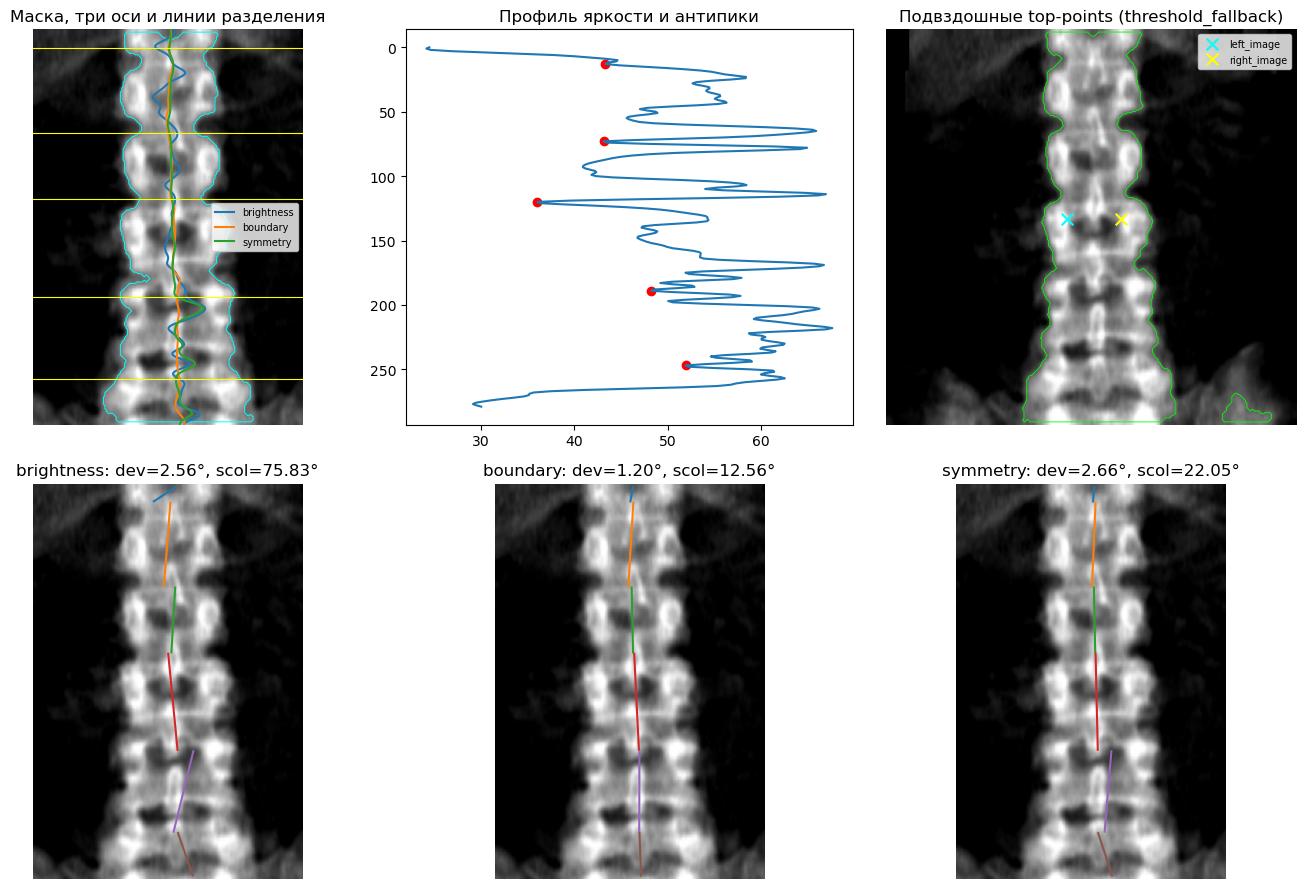

dicom_path                                C:\Users\Андрей\Desktop\Хакатон\Исследования\1...
pixel_spacing_available                                                               False
spine_content_top_y_px                                                                    2
spine_content_bottom_y_px                                                               277
separator_count                                                                           5
visible_segment_count                                                                     6
separator_median_gap_px                                                                59.0
t12_top_to_first_separator_px                                                          11.0
t12_half_ratio                                                                     0.186441
separator_min_gap_px                                                                     29
separator_prominence                                                            

In [9]:
spine_candidates = representatives.loc[representatives["target_anatomy"].eq("SPINE")]
SPINE_EXAMPLE_PATH = Path(spine_candidates.iloc[0]["dicom_path"]) if len(spine_candidates) else None
if SPINE_EXAMPLE_PATH is not None:
    show_spine_diagnostics(SPINE_EXAMPLE_PATH, use_sam=USE_SAM)
else:
    print("Не найден пример SPINE")

# Опциональный перебор параметров именно разделения на позвонки.
# Включайте после визуальной проверки одного примера: 27 вариантов × до 25 снимков.
RUN_SPINE_SEGMENTATION_SWEEP = False
if RUN_SPINE_SEGMENTATION_SWEEP and len(spine_candidates):
    segmentation_grid = {
        "bright_fraction": [0.07, 0.10, 0.13],
        "separator_min_gap_ratio": [0.085, 0.105, 0.125],
        "separator_prominence_std": [0.04, 0.08, 0.12],
    }
    sweep_rows = []
    sweep_cases = spine_candidates.sample(
        n=min(25, len(spine_candidates)), random_state=RANDOM_SEED
    )
    for variant_id, variant in enumerate(ParameterGrid(segmentation_grid)):
        extracted = []
        for row in sweep_cases.itertuples(index=False):
            try:
                extracted.append(extract_spine_features(
                    row.dicom_path, params=variant, use_sam=False
                ))
            except Exception:
                pass
        table = pd.DataFrame(extracted)
        if table.empty:
            continue
        method_disagreement = table[[
            "axis_deviation_vertical_deg_brightness",
            "axis_deviation_vertical_deg_boundary",
            "axis_deviation_vertical_deg_symmetry",
        ]].max(axis=1) - table[[
            "axis_deviation_vertical_deg_brightness",
            "axis_deviation_vertical_deg_boundary",
            "axis_deviation_vertical_deg_symmetry",
        ]].min(axis=1)
        sweep_rows.append({
            "variant_id": variant_id,
            **variant,
            "success_rate": len(table) / len(sweep_cases),
            "plausible_separator_rate": table["separator_count"].between(5, 6).mean(),
            "median_separator_count": table["separator_count"].median(),
            "median_t12_half_ratio": table["t12_half_ratio"].median(),
            "median_axis_method_disagreement_deg": method_disagreement.median(),
        })
    segmentation_sweep = pd.DataFrame(sweep_rows)
    segmentation_sweep["stability_score"] = (
        segmentation_sweep["success_rate"]
        + segmentation_sweep["plausible_separator_rate"]
        - 0.05 * segmentation_sweep["median_axis_method_disagreement_deg"]
    )
    display(segmentation_sweep.sort_values("stability_score", ascending=False).head(20))


### Пакетное извлечение признаков позвоночника

При включённом SAM этот этап может занимать заметное время. Результат сохраняется в CSV.
`iliac_method` обязательно проверяется: пороги, подобранные на threshold-fallback, нельзя
автоматически переносить на SAM-маски.


In [10]:
spine_cache = OUTPUT_DIR / "spine_features.csv"
spine_source = representatives.loc[representatives["target_anatomy"].eq("SPINE")].copy()

if spine_cache.exists() and not FORCE_RECOMPUTE:
    spine_features = pd.read_csv(spine_cache, low_memory=False)
    print("Загружен кэш:", spine_cache)
else:
    rows = []
    for row in tqdm(spine_source.itertuples(index=False), total=len(spine_source), desc="Spine features"):
        base = {
            "source_row_id": row.source_row_id,
            "selection_study": row.selection_study,
            "task_study": row.task_study,
            "dicom_group": row.dicom_group,
            "dicom_path": str(row.dicom_path),
        }
        for target in ("spine_coverage", "spine_alignment", "spine_artifacts", "scoliosis_from_comment"):
            base[target] = getattr(row, target, np.nan)
        try:
            features = extract_spine_features(row.dicom_path, use_sam=USE_SAM)
            rows.append({**base, **features, "processing_status": "Success"})
        except Exception as exc:
            rows.append({**base, "processing_status": "Failure",
                         "error_type": type(exc).__name__, "error_message": str(exc)})
    spine_features = pd.DataFrame(rows)
    spine_features.to_csv(spine_cache, index=False, encoding="utf-8-sig")
    print("Сохранено:", spine_cache)

display(pd.DataFrame({
    "value": {
        "cases": len(spine_features),
        "success": int(spine_features["processing_status"].eq("Success").sum()),
        "linked_targets": int(spine_features["task_study"].notna().sum()),
        "sam_masks": int(spine_features.get("iliac_method", pd.Series(dtype=str)).eq("sam_vit_b").sum()),
    }
}))
display(spine_features.head())


Spine features:   0%|          | 0/99 [00:00<?, ?it/s]

Сохранено: C:\Users\Андрей\Desktop\Хакатон\prototype_output\target_tuning\spine_features.csv


,value
cases,99
success,99
linked_targets,99
sam_masks,0


,source_row_id,selection_study,task_study,dicom_group,dicom_path,spine_coverage,spine_alignment,spine_artifacts,scoliosis_from_comment,pixel_spacing_available,...,iliac_left_image_top_x_px,iliac_left_image_top_y_px,iliac_left_image_top_y_norm,iliac_left_image_sam_score,iliac_right_image_area_fraction,iliac_right_image_top_x_px,iliac_right_image_top_y_px,iliac_right_image_top_y_norm,iliac_right_image_sam_score,processing_status
0,0,1.2.840.113619.2.110.512719.20250403090444,1.2.840.113619.2.110.512719.20250403090444,1.2.840.113619.2.110.512719.20250403090444,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,0.0,0.0,0.0,0,False,...,132.0,138.0,0.477509,NaN,0.079250,171.5,138.0,0.477509,NaN,Success
1,7,1.2.840.113619.2.110.512719.20250403092052,1.2.840.113619.2.110.512719.20250403092052,1.2.840.113619.2.110.512719.20250403092052,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,0.0,0.0,0.0,0,False,...,133.5,152.0,0.477987,NaN,0.061059,166.0,152.0,0.477987,NaN,Success
2,15,1.2.840.113619.2.110.512719.20250407113211,1.2.840.113619.2.110.512719.20250407113211,1.2.840.113619.2.110.512719.20250407113211,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,0.0,0.0,0.0,0,False,...,126.0,139.0,0.477663,NaN,0.057148,167.0,139.0,0.477663,NaN,Success
3,19,2.25.10245777060263212829333021434108890537,2.25.10245777060263212829333021434108890537,2.25.10245777060263212829333021434108890537,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.0,0.0,0.0,0,False,...,132.0,152.0,0.477987,NaN,0.075294,171.0,152.0,0.477987,NaN,Success
4,22,2.25.102755089973625799055786462646268820450,2.25.102755089973625799055786462646268820450,2.25.102755089973625799055786462646268820450,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.0,1.0,0.0,0,False,...,148.5,165.0,0.574913,NaN,0.072753,183.5,137.0,0.477352,NaN,Success


## 4. Таргет 1: корректная укладка позвоночника

Начальное правило считает укладку корректной, если:

- найдено 5–6 межпозвонковых линий;
- отношение видимой части Th12 находится между `t12_low` и `t12_high`;
- площади обеих подвздошных масок находятся в заданном диапазоне;
- верхние точки обеих подвздошных масок находятся в допустимой вертикальной зоне;
- две маски не совпадают друг с другом.

Все пороги, кроме структурного числа линий, перебираются по разметке.


In [11]:
def spine_coverage_rule(frame, params):
    required = [
        "separator_count", "t12_half_ratio",
        "iliac_left_image_area_fraction", "iliac_right_image_area_fraction",
        "iliac_left_image_top_y_norm", "iliac_right_image_top_y_norm", "iliac_pair_iou",
    ]
    available = frame[required].apply(pd.to_numeric, errors="coerce").notna().all(axis=1)
    correct = (
        frame["separator_count"].between(params["separator_min"], params["separator_max"])
        & frame["t12_half_ratio"].between(params["t12_low"], params["t12_high"])
        & frame["iliac_left_image_area_fraction"].between(params["area_low"], params["area_high"])
        & frame["iliac_right_image_area_fraction"].between(params["area_low"], params["area_high"])
        & frame["iliac_left_image_top_y_norm"].between(params["top_low"], params["top_high"])
        & frame["iliac_right_image_top_y_norm"].between(params["top_low"], params["top_high"])
        & (frame["iliac_pair_iou"] <= params["max_pair_iou"])
    )
    prediction = pd.Series(np.nan, index=frame.index)
    prediction.loc[available] = (~correct.loc[available]).astype(int)
    return prediction


coverage_grid = {
    "separator_min": [5],
    "separator_max": [6],
    "t12_low": [0.20, 0.30, 0.40],
    "t12_high": [0.65, 0.80, 0.95],
    "area_low": [0.002, 0.005, 0.010],
    "area_high": [0.08, 0.15, 0.25],
    "top_low": [0.42, 0.50],
    "top_high": [0.86, 0.94],
    "max_pair_iou": [0.10, 0.20],
}
coverage_search = grid_search_rule(
    spine_features, "spine_coverage", spine_coverage_rule, coverage_grid
)
coverage_oof, coverage_choices = grouped_oof_grid_search(
    spine_features, "spine_coverage", "selection_study",
    spine_coverage_rule, coverage_grid
)
show_grid_result("Таргет 1: укладка позвоночника", coverage_search, coverage_oof, coverage_choices)


Таргет 1: укладка позвоночника


,area_high,area_low,max_pair_iou,separator_max,separator_min,t12_high,t12_low,top_high,top_low,n,...,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,0.15,0.002,0.1,6,5,0.8,0.2,0.86,0.42,99,...,0,6,0.434343,1.0,0.397849,0.096774,0.698925,0.176471,0.348837,0.523881
1,0.15,0.002,0.1,6,5,0.8,0.2,0.94,0.42,99,...,0,6,0.434343,1.0,0.397849,0.096774,0.698925,0.176471,0.348837,0.523881
2,0.15,0.002,0.2,6,5,0.8,0.2,0.86,0.42,99,...,0,6,0.434343,1.0,0.397849,0.096774,0.698925,0.176471,0.348837,0.523881
3,0.15,0.002,0.2,6,5,0.8,0.2,0.94,0.42,99,...,0,6,0.434343,1.0,0.397849,0.096774,0.698925,0.176471,0.348837,0.523881
4,0.15,0.005,0.1,6,5,0.8,0.2,0.86,0.42,99,...,0,6,0.434343,1.0,0.397849,0.096774,0.698925,0.176471,0.348837,0.523881
5,0.15,0.005,0.1,6,5,0.8,0.2,0.94,0.42,99,...,0,6,0.434343,1.0,0.397849,0.096774,0.698925,0.176471,0.348837,0.523881
6,0.15,0.005,0.2,6,5,0.8,0.2,0.86,0.42,99,...,0,6,0.434343,1.0,0.397849,0.096774,0.698925,0.176471,0.348837,0.523881
7,0.15,0.005,0.2,6,5,0.8,0.2,0.94,0.42,99,...,0,6,0.434343,1.0,0.397849,0.096774,0.698925,0.176471,0.348837,0.523881
8,0.15,0.010,0.1,6,5,0.8,0.2,0.86,0.42,99,...,0,6,0.434343,1.0,0.397849,0.096774,0.698925,0.176471,0.348837,0.523881
9,0.15,0.010,0.1,6,5,0.8,0.2,0.94,0.42,99,...,0,6,0.434343,1.0,0.397849,0.096774,0.698925,0.176471,0.348837,0.523881


,evaluation,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,group_oof,99,6,38,55,1,5,0.434343,0.833333,0.408602,0.083333,0.620968,0.151515,0.297619,0.459293


,fold,test_n,separator_min,separator_max,t12_low,t12_high,area_low,area_high,top_low,top_high,max_pair_iou
0,0,20,5.0,6.0,0.2,0.80,0.002,0.15,0.42,0.86,0.1
1,1,20,5.0,6.0,0.2,0.95,0.002,0.15,0.42,0.86,0.1
2,2,20,5.0,6.0,0.2,0.80,0.002,0.15,0.42,0.86,0.1
3,3,20,5.0,6.0,0.2,0.80,0.002,0.15,0.42,0.86,0.1
4,4,19,5.0,6.0,0.2,0.80,0.002,0.15,0.42,0.86,0.1


## 5. Таргет 2: ось позвоночника

Для каждого метода считается угол общей оси с горизонталью и отклонение от вертикали:

`deviation = |90° − angle_to_horizontal|`.

Поле Excel содержит ориентир «до 5°», поэтому 5° включён в сетку как исходная гипотеза.
Перебор одновременно выбирает способ построения оси и порог.


Таргет 2: ось позвоночника


,max_deviation_deg,method,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,4.0,boundary,99,10,62,27,2,8,0.707071,0.8,0.696629,0.228571,0.748315,0.355556,0.533333,0.640824
1,5.0,boundary,99,10,67,22,3,7,0.747475,0.7,0.752809,0.241379,0.726404,0.358974,0.507246,0.616825
2,3.0,boundary,99,10,51,38,2,8,0.595960,0.8,0.573034,0.173913,0.686517,0.285714,0.465116,0.575817
3,2.0,boundary,99,10,36,53,1,9,0.454545,0.9,0.404494,0.145161,0.652247,0.250000,0.441176,0.546712
4,6.0,boundary,99,10,74,15,5,5,0.797980,0.5,0.831461,0.250000,0.665730,0.333333,0.416667,0.541199
5,3.0,symmetry,99,10,49,40,3,7,0.565657,0.7,0.550562,0.148936,0.625281,0.245614,0.402299,0.513790
6,4.0,symmetry,99,10,55,34,4,6,0.616162,0.6,0.617978,0.150000,0.608989,0.240000,0.375000,0.491994
7,5.0,symmetry,99,10,64,25,5,5,0.696970,0.5,0.719101,0.166667,0.609551,0.250000,0.357143,0.483347
8,6.0,symmetry,99,10,75,14,6,4,0.797980,0.4,0.842697,0.222222,0.621348,0.285714,0.344828,0.483088
9,8.0,symmetry,99,10,86,3,7,3,0.898990,0.3,0.966292,0.500000,0.633146,0.375000,0.326087,0.479617


,evaluation,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,group_oof,99,10,65,24,5,5,0.707071,0.5,0.730337,0.172414,0.615169,0.25641,0.362319,0.488744


,fold,test_n,method,max_deviation_deg
0,0,20,boundary,6.0
1,1,20,boundary,4.0
2,2,20,boundary,5.0
3,3,20,boundary,4.0
4,4,19,boundary,4.0


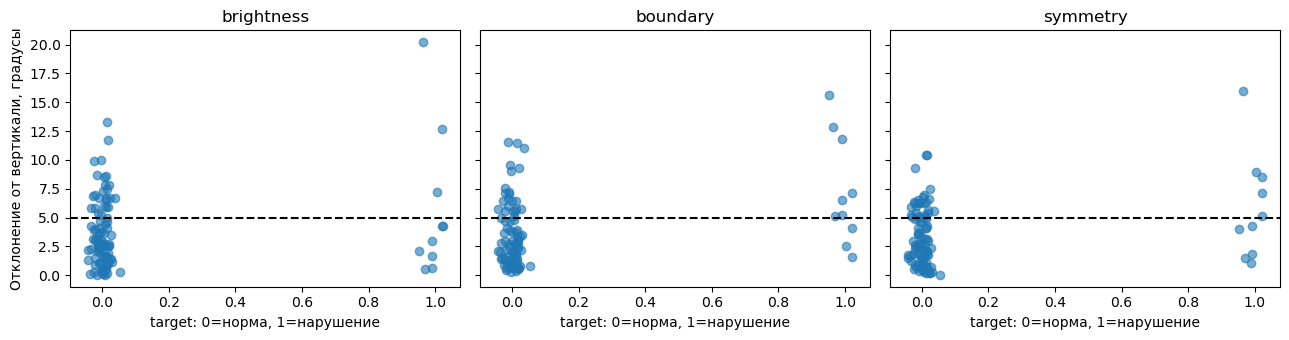

In [12]:
def spine_alignment_rule(frame, params):
    column = f"axis_deviation_vertical_deg_{params['method']}"
    values = pd.to_numeric(frame[column], errors="coerce")
    prediction = pd.Series(np.nan, index=frame.index)
    prediction.loc[values.notna()] = (values.loc[values.notna()] > params["max_deviation_deg"]).astype(int)
    return prediction


alignment_grid = {
    "method": ["brightness", "boundary", "symmetry"],
    "max_deviation_deg": [2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0],
}
alignment_search = grid_search_rule(
    spine_features, "spine_alignment", spine_alignment_rule, alignment_grid
)
alignment_oof, alignment_choices = grouped_oof_grid_search(
    spine_features, "spine_alignment", "selection_study",
    spine_alignment_rule, alignment_grid
)
show_grid_result("Таргет 2: ось позвоночника", alignment_search, alignment_oof, alignment_choices)

if "spine_alignment" in spine_features:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
    target = normalize_target(spine_features["spine_alignment"])
    for axis, method in zip(axes, alignment_grid["method"]):
        values = pd.to_numeric(spine_features[f"axis_deviation_vertical_deg_{method}"], errors="coerce")
        axis.scatter(target + np.random.default_rng(RANDOM_SEED).normal(0, 0.025, len(target)), values, alpha=0.6)
        axis.axhline(5, color="black", linestyle="--")
        axis.set_title(method)
        axis.set_xlabel("target: 0=норма, 1=нарушение")
    axes[0].set_ylabel("Отклонение от вертикали, градусы")
    plt.tight_layout()
    plt.show()


## 6. Таргет 3: посторонние предметы и артефакты

Используются четыре интерпретируемых признака сегментации:

- площадь крупнейшей яркой компоненты вне основной анатомии;
- общая доля ярких пикселей вне основной анатомии;
- яркие пиксели на границе кадра;
- концентрация направлений сильных градиентов, чувствительная к длинным прямым объектам.

Показаны два baseline: логическое правило с перебором порогов и неглубокое дерево решений.
Дерево ограничено глубиной 2, чтобы условия можно было прочитать и проверить визуально.


Таргет 3: артефакты, логическое правило


,border_bright_max,extra_component_max,orientation_max,outside_bright_max,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,0.000844,0.000145,0.332484,0.000153,99,17,52,30,5,12,0.646465,0.705882,0.634146,0.285714,0.670014,0.406780,0.545455,0.607734
1,0.000844,0.000000,0.332484,0.000000,99,17,51,31,5,12,0.636364,0.705882,0.621951,0.279070,0.663917,0.400000,0.540541,0.602229
2,0.000844,0.000000,0.332484,0.000153,99,17,51,31,5,12,0.636364,0.705882,0.621951,0.279070,0.663917,0.400000,0.540541,0.602229
3,0.000844,0.000145,0.332484,0.000000,99,17,51,31,5,12,0.636364,0.705882,0.621951,0.279070,0.663917,0.400000,0.540541,0.602229
4,0.000844,0.000145,0.297209,0.000153,99,17,46,36,5,12,0.585859,0.705882,0.560976,0.250000,0.633429,0.369231,0.517241,0.575335
5,0.000844,0.000000,0.297209,0.000000,99,17,45,37,5,12,0.575758,0.705882,0.548780,0.244898,0.627331,0.363636,0.512821,0.570076
6,0.000844,0.000000,0.297209,0.000153,99,17,45,37,5,12,0.575758,0.705882,0.548780,0.244898,0.627331,0.363636,0.512821,0.570076
7,0.000844,0.000145,0.297209,0.000000,99,17,45,37,5,12,0.575758,0.705882,0.548780,0.244898,0.627331,0.363636,0.512821,0.570076
8,0.000844,0.000145,0.245302,0.000153,99,17,33,49,5,12,0.454545,0.705882,0.402439,0.196721,0.554161,0.307692,0.465116,0.509638
9,0.000844,0.000000,0.245302,0.000000,99,17,32,50,5,12,0.444444,0.705882,0.390244,0.193548,0.548063,0.303797,0.461538,0.504801


,evaluation,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,group_oof,99,17,51,31,5,12,0.636364,0.705882,0.621951,0.27907,0.663917,0.4,0.540541,0.602229


,fold,test_n,extra_component_max,outside_bright_max,border_bright_max,orientation_max
0,0,20,0.000145,0.000153,0.000844,0.332484
1,1,20,0.000000,0.000000,0.000844,0.332484
2,2,20,0.000145,0.000153,0.000844,0.332484
3,3,20,0.000145,0.000153,0.000844,0.332484
4,4,19,0.000145,0.000153,0.000844,0.332484


,evaluation,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,shallow_tree_group_oof,99,17,66,16,9,8,0.747475,0.470588,0.804878,0.333333,0.637733,0.390244,0.434783,0.536258


|--- artifact_orientation_concentration <= 0.21
|   |--- artifact_border_bright_fraction <= 0.00
|   |   |--- class: 0
|   |--- artifact_border_bright_fraction >  0.00
|   |   |--- class: 1
|--- artifact_orientation_concentration >  0.21
|   |--- artifact_orientation_concentration <= 0.35
|   |   |--- class: 0
|   |--- artifact_orientation_concentration >  0.35
|   |   |--- class: 1



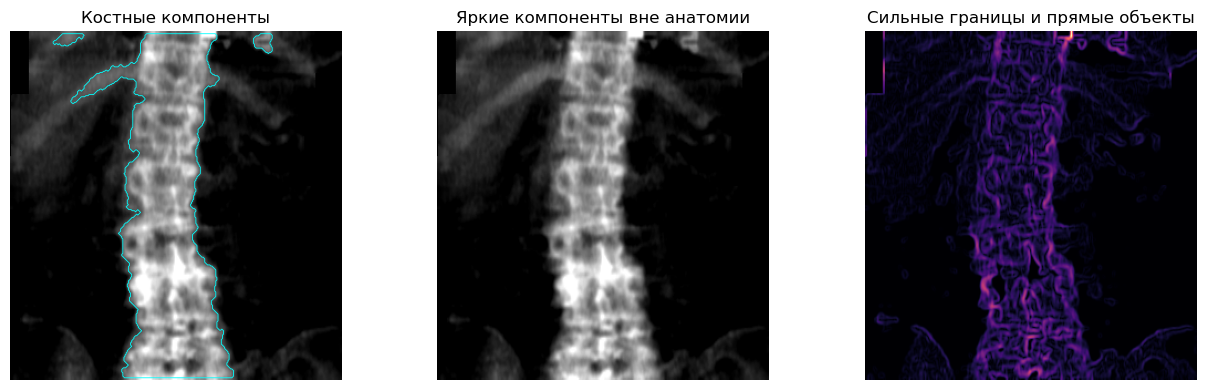

In [13]:
artifact_feature_columns = [
    "artifact_extra_component_fraction",
    "artifact_outside_bright_fraction",
    "artifact_border_bright_fraction",
    "artifact_orientation_concentration",
]


def artifact_rule(frame, params):
    numeric = frame[artifact_feature_columns].apply(pd.to_numeric, errors="coerce")
    available = numeric.notna().all(axis=1)
    violation = (
        (numeric["artifact_extra_component_fraction"] > params["extra_component_max"])
        | (numeric["artifact_outside_bright_fraction"] > params["outside_bright_max"])
        | (numeric["artifact_border_bright_fraction"] > params["border_bright_max"])
        | (numeric["artifact_orientation_concentration"] > params["orientation_max"])
    )
    prediction = pd.Series(np.nan, index=frame.index)
    prediction.loc[available] = violation.loc[available].astype(int)
    return prediction


artifact_grid = {
    "extra_component_max": quantile_grid(spine_features.get("artifact_extra_component_fraction", pd.Series(dtype=float)), (0.55, 0.75, 0.90, 0.96)),
    "outside_bright_max": quantile_grid(spine_features.get("artifact_outside_bright_fraction", pd.Series(dtype=float)), (0.55, 0.75, 0.90, 0.96)),
    "border_bright_max": quantile_grid(spine_features.get("artifact_border_bright_fraction", pd.Series(dtype=float)), (0.65, 0.85, 0.95)),
    "orientation_max": quantile_grid(spine_features.get("artifact_orientation_concentration", pd.Series(dtype=float)), (0.65, 0.85, 0.95)),
}
if all(artifact_grid.values()):
    artifact_search = grid_search_rule(
        spine_features, "spine_artifacts", artifact_rule, artifact_grid
    )
    artifact_oof, artifact_choices = grouped_oof_grid_search(
        spine_features, "spine_artifacts", "selection_study",
        artifact_rule, artifact_grid
    )
else:
    artifact_search, artifact_oof, artifact_choices = pd.DataFrame(), None, pd.DataFrame()
show_grid_result("Таргет 3: артефакты, логическое правило", artifact_search, artifact_oof, artifact_choices)


def fit_shallow_tree_oof(frame, target_col, feature_columns, group_col, max_depth=2):
    target = normalize_target(frame[target_col])
    numeric = frame[feature_columns].apply(pd.to_numeric, errors="coerce")
    valid = target.isin([0, 1]) & numeric.notna().all(axis=1) & frame[group_col].notna()
    work = frame.loc[valid].copy()
    x = numeric.loc[valid].to_numpy(float)
    y = target.loc[valid].astype(int).to_numpy()
    groups = work[group_col].to_numpy()
    counts = pd.Series(y).value_counts()
    group_counts = work.assign(_target=y).groupby("_target")[group_col].nunique()
    if len(counts) < 2 or len(group_counts) < 2 or group_counts.min() < 2:
        return None, None, "Недостаточно групп для cross-validation"
    splitter = StratifiedGroupKFold(
        n_splits=min(5, int(group_counts.min())), shuffle=True, random_state=RANDOM_SEED
    )
    oof = np.full(len(work), -1, dtype=int)
    for train_idx, test_idx in splitter.split(x, y, groups=groups):
        model = DecisionTreeClassifier(
            max_depth=max_depth, min_samples_leaf=max(2, len(train_idx) // 20),
            class_weight="balanced", random_state=RANDOM_SEED
        )
        model.fit(x[train_idx], y[train_idx])
        oof[test_idx] = model.predict(x[test_idx])
    metrics = binary_metrics(y[oof >= 0], oof[oof >= 0])
    final_model = DecisionTreeClassifier(
        max_depth=max_depth, min_samples_leaf=max(2, len(work) // 20),
        class_weight="balanced", random_state=RANDOM_SEED
    ).fit(x, y)
    rules = export_text(final_model, feature_names=feature_columns)
    return metrics, final_model, rules


if "spine_artifacts" in spine_features:
    artifact_tree_metrics, artifact_tree, artifact_tree_rules = fit_shallow_tree_oof(
        spine_features, "spine_artifacts", artifact_feature_columns, "selection_study"
    )
    if artifact_tree_metrics is not None:
        display(pd.DataFrame([{"evaluation": "shallow_tree_group_oof", **artifact_tree_metrics}]))
        print(artifact_tree_rules)
    else:
        print(artifact_tree_rules)


def show_artifact_diagnostics(path):
    _, image, filtered, _ = load_image(path)
    anatomy_mask = build_bone_mask(filtered, SPINE_PARAMS["bone_quantile"], keep_largest=False)
    main = component_filter(anatomy_mask, keep_largest=True)
    corridor = binary_dilation(
        main, iterations=max(2, int(round(min(image.shape) * 0.015)))
    )
    positive = image[image > 0]
    threshold = np.quantile(positive, 0.985)
    bright = image >= threshold
    outside = component_filter(bright & ~corridor, min_area_fraction=0.00005)
    gx, gy = sobel(image, axis=1), sobel(image, axis=0)
    gradient = np.hypot(gx, gy)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(image, cmap="gray")
    axes[0].contour(anatomy_mask, levels=[0.5], colors="cyan", linewidths=0.6)
    axes[0].set_title("Костные компоненты")
    axes[1].imshow(image, cmap="gray")
    axes[1].imshow(np.ma.masked_where(~outside, outside), cmap="autumn", alpha=0.55)
    axes[1].set_title("Яркие компоненты вне анатомии")
    axes[2].imshow(gradient, cmap="magma")
    axes[2].set_title("Сильные границы и прямые объекты")
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()
    plt.show()


artifact_examples = spine_features.loc[
    normalize_target(spine_features["spine_artifacts"]).eq(1)
] if "spine_artifacts" in spine_features else pd.DataFrame()
if len(artifact_examples):
    show_artifact_diagnostics(artifact_examples.iloc[0]["dicom_path"])


## 7. Таргет 4: сколиоз

Прокси-угол равен модулю разности наклонов локальных осей первого и последнего видимых
сегментов. Сравниваются те же три способа построения оси. Таргет извлекается из комментария,
поэтому он слабее обычной экспертной бинарной разметки и требует ручной проверки случаев.


In [14]:
def scoliosis_rule(frame, params):
    column = f"scoliosis_angle_deg_{params['method']}"
    values = pd.to_numeric(frame[column], errors="coerce")
    prediction = pd.Series(np.nan, index=frame.index)
    prediction.loc[values.notna()] = (values.loc[values.notna()] > params["angle_threshold_deg"]).astype(int)
    return prediction


scoliosis_grid = {
    "method": ["brightness", "boundary", "symmetry"],
    "angle_threshold_deg": [3.0, 5.0, 7.0, 10.0, 12.0, 15.0, 20.0],
}
scoliosis_search = grid_search_rule(
    spine_features, "scoliosis_from_comment", scoliosis_rule, scoliosis_grid
)
scoliosis_oof, scoliosis_choices = grouped_oof_grid_search(
    spine_features, "scoliosis_from_comment", "selection_study",
    scoliosis_rule, scoliosis_grid
)
show_grid_result("Таргет 4: сколиоз", scoliosis_search, scoliosis_oof, scoliosis_choices)


Таргет 4: сколиоз


,angle_threshold_deg,method,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,20.0,boundary,99,14,49,36,3,11,0.606061,0.785714,0.576471,0.234043,0.681092,0.360656,0.533981,0.607537
1,15.0,boundary,99,14,42,43,3,11,0.535354,0.785714,0.494118,0.203704,0.639916,0.323529,0.500000,0.569958
2,12.0,boundary,99,14,35,50,3,11,0.464646,0.785714,0.411765,0.180328,0.598739,0.293333,0.470085,0.534412
3,10.0,boundary,99,14,31,54,3,11,0.424242,0.785714,0.364706,0.169231,0.575210,0.278481,0.454545,0.514878
4,5.0,symmetry,99,14,13,72,1,13,0.262626,0.928571,0.152941,0.152941,0.540756,0.262626,0.460993,0.500875
5,5.0,boundary,99,14,18,67,2,12,0.303030,0.857143,0.211765,0.151899,0.534454,0.258065,0.444444,0.489449
6,7.0,boundary,99,14,22,63,3,11,0.333333,0.785714,0.258824,0.148649,0.522269,0.250000,0.423077,0.472673
7,3.0,boundary,99,14,12,73,2,12,0.242424,0.857143,0.141176,0.141176,0.499160,0.242424,0.425532,0.462346
8,3.0,symmetry,99,14,4,81,1,13,0.171717,0.928571,0.047059,0.138298,0.487815,0.240741,0.433333,0.460574
9,15.0,symmetry,99,14,33,52,5,9,0.424242,0.642857,0.388235,0.147541,0.515546,0.240000,0.384615,0.450081


,evaluation,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,group_oof,99,14,49,36,3,11,0.606061,0.785714,0.576471,0.234043,0.681092,0.360656,0.533981,0.607537


,fold,test_n,method,angle_threshold_deg
0,0,20,boundary,20.0
1,1,20,boundary,20.0
2,2,20,boundary,20.0
3,3,19,boundary,20.0
4,4,20,boundary,20.0


## 8. Бедро: исходная схема и начальные диапазоны

На первой схеме: `1` — большой вертел, `2` — шейка бедра, `3` — седалищная кость.
Вторая схема задаёт клинические границы ROI: 3 см сверху, 3 см снизу и 2 см латерально.

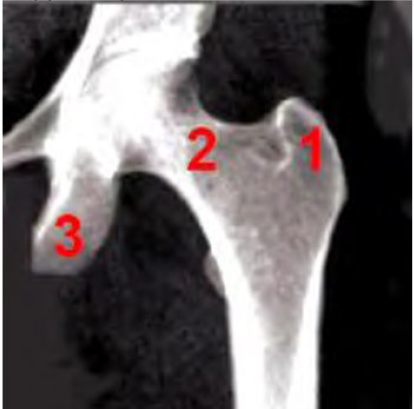

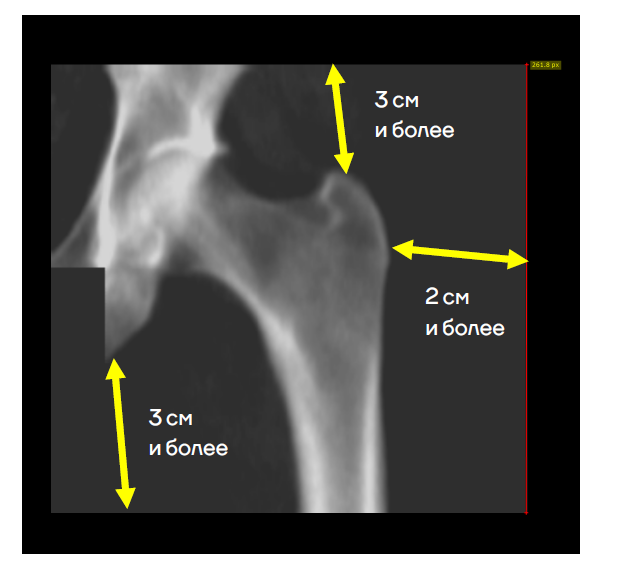

Из схемы берутся только начальные геометрические диапазоны:

- седалищная кость находится слева от бедренной кости после приведения к каноническому
  виду левого бедра;
- её ширина на горизонтальном срезе ожидается примерно в диапазоне 4–22% ширины кадра;
- шейка анализируется срезами под 60° к горизонтали;
- большой вертел — срезами под −70°;
- ротация оценивается по выступанию малого вертела в координатах, повёрнутых на 60°.

Эти значения не считаются окончательными: они входят в перебор и проверяются по разметке.


### Каноническая ориентация и признаки

Правое бедро зеркально отражается, поэтому в каноническом изображении большой вертел
всегда находится справа, а седалищная кость — слева. Визуализация и численные признаки
после этого одинаковы для обеих сторон.


In [15]:
HIP_PARAMS = {
    "bone_quantile": 0.56,
    "ischial_y_low": 0.34,
    "ischial_y_high": 0.88,
    "min_run_ratio": 0.012,
    "neck_angle_deg": 60.0,
    "neck_center_x": 0.47,
    "neck_center_y": 0.36,
    "neck_offset_ratio": 0.20,
    "trochanter_angle_deg": -70.0,
    "trochanter_center_x": 0.68,
    "trochanter_center_y": 0.38,
    "trochanter_offset_ratio": 0.18,
    "rotation_angle_deg": 60.0,
    "shaft_y_low": 0.43,
    "shaft_y_high": 0.92,
}


def canonicalize_hip(image, side):
    side = str(side).upper()
    if side in {"RIGHT", "LEG_RIGHT"}:
        return np.fliplr(image).copy(), True
    return image.copy(), False


def row_intervals(row, min_length):
    return boolean_runs(row, min_length=min_length)


def ischial_horizontal_features(mask, params):
    h, w = mask.shape
    y0 = int(params["ischial_y_low"] * h)
    y1 = int(params["ischial_y_high"] * h)
    min_run = max(2, int(round(params["min_run_ratio"] * w)))
    valid_rows = []
    row_records = []
    for y in range(y0, y1):
        intervals = row_intervals(mask[y], min_run)
        # После очистки ожидаются ровно две анатомические компоненты, то есть 4 границы.
        if len(intervals) != 2:
            continue
        left, right = intervals
        left_center = 0.5 * (left[0] + left[1])
        right_center = 0.5 * (right[0] + right[1])
        if left_center >= right_center or left_center > 0.62 * w or right_center < 0.35 * w:
            continue
        valid_rows.append(y)
        row_records.append({
            "y": y,
            "x1": left[0], "x2": left[1], "x3": right[0], "x4": right[1],
            "ischial_width_ratio": (left[1] - left[0] + 1) / w,
            "gap_ratio": (right[0] - left[1] - 1) / w,
            "femur_width_ratio": (right[1] - right[0] + 1) / w,
        })
    table = pd.DataFrame(row_records)
    valid_mask = np.zeros(h, dtype=bool)
    valid_mask[valid_rows] = True
    runs = boolean_runs(valid_mask)
    longest = max((stop - start + 1 for start, stop in runs), default=0)
    return {
        "four_boundary_row_fraction": len(valid_rows) / h,
        "four_boundary_longest_span_ratio": longest / h,
        "ischial_width_ratio": float(table["ischial_width_ratio"].median()) if len(table) else np.nan,
        "ischial_gap_ratio": float(table["gap_ratio"].median()) if len(table) else np.nan,
        "femur_width_ratio": float(table["femur_width_ratio"].median()) if len(table) else np.nan,
        "_table": table,
    }


def oriented_width_profile(mask, center_xy, angle_deg, offset_ratio, half_length_ratio=0.42):
    h, w = mask.shape
    theta = np.deg2rad(angle_deg)
    direction = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    perpendicular = np.array([-np.sin(theta), np.cos(theta)], dtype=float)
    scale = min(h, w)
    offsets = np.arange(-int(offset_ratio * scale), int(offset_ratio * scale) + 1)
    half = max(10, int(round(half_length_ratio * scale)))
    t = np.arange(-half, half + 1, dtype=float)
    widths, lines = [], []
    center_xy = np.asarray(center_xy, dtype=float)
    for offset in offsets:
        center = center_xy + offset * perpendicular
        xs = center[0] + t * direction[0]
        ys = center[1] + t * direction[1]
        sampled = map_coordinates(mask.astype(float), [ys, xs], order=0, mode="constant", cval=0) > 0.5
        width, start, stop = longest_true_run(sampled)
        if width > 0:
            p1 = center + t[start] * direction
            p2 = center + t[stop] * direction
        else:
            p1 = p2 = np.array([np.nan, np.nan])
        widths.append(width)
        lines.append((p1, p2, center))
    return np.asarray(offsets), np.asarray(widths, dtype=float), lines


def narrowing_features(offsets, widths, lines):
    valid = widths >= 3
    if valid.sum() < 7:
        return {
            "min_width_px": np.nan,
            "narrowing_ratio": np.nan,
            "adjacent_thickening_ratio": np.nan,
            "best_line": None,
            "best_offset": np.nan,
        }
    smooth = median_filter(np.where(valid, widths, np.nanmax(widths) + 1), size=5, mode="nearest")
    candidate_indices = np.flatnonzero(valid)
    best_index = int(candidate_indices[np.argmin(smooth[candidate_indices])])
    radius = max(3, len(widths) // 10)
    left = widths[max(0, best_index - 2 * radius):max(0, best_index - radius)]
    right = widths[min(len(widths), best_index + radius):min(len(widths), best_index + 2 * radius)]
    left = left[left >= 3]
    right = right[right >= 3]
    adjacent = [np.median(values) for values in (left, right) if len(values)]
    adjacent_width = min(adjacent) if len(adjacent) == 2 else (adjacent[0] if adjacent else np.nan)
    minimum = widths[best_index]
    return {
        "min_width_px": float(minimum),
        "narrowing_ratio": float(minimum / adjacent_width) if np.isfinite(adjacent_width) and adjacent_width else np.nan,
        "adjacent_thickening_ratio": float(adjacent_width / minimum) if np.isfinite(adjacent_width) and minimum else np.nan,
        "best_line": lines[best_index],
        "best_offset": float(offsets[best_index]),
    }


def shaft_boundary_points(mask, params):
    h, w = mask.shape
    rows = []
    for y in range(int(params["shaft_y_low"] * h), int(params["shaft_y_high"] * h)):
        intervals = row_intervals(mask[y], max(2, int(0.012 * w)))
        if not intervals:
            continue
        # Бедренная кость — наиболее правая крупная компонента в каноническом виде.
        interval = max(intervals, key=lambda pair: (pair[1], pair[1] - pair[0]))
        rows.append({"y": y, "left_x": interval[0], "right_x": interval[1],
                     "width": interval[1] - interval[0] + 1})
    return pd.DataFrame(rows)


def rotation_prominence_features(mask, params):
    table = shaft_boundary_points(mask, params)
    if len(table) < 12:
        return {"rotation_prominence_ratio": np.nan, "rotation_bump_x": np.nan,
                "rotation_bump_y": np.nan, "_shaft": table}
    h, _ = mask.shape
    lower = table["y"] >= np.quantile(table["y"], 0.68)
    theta = np.deg2rad(params["rotation_angle_deg"])
    x = table["left_x"].to_numpy(float)
    y_up = -table["y"].to_numpy(float)
    u = x * np.cos(theta) + y_up * np.sin(theta)
    v = -x * np.sin(theta) + y_up * np.cos(theta)
    if lower.sum() < 3:
        lower[:] = True
    slope, intercept = np.polyfit(u[lower], v[lower], 1)
    residual = (slope * u + intercept) - v
    bump_zone = table["y"].between(0.46 * h, 0.72 * h).to_numpy()
    if not bump_zone.any():
        return {"rotation_prominence_ratio": np.nan, "rotation_bump_x": np.nan,
                "rotation_bump_y": np.nan, "_shaft": table}
    zone_indices = np.flatnonzero(bump_zone)
    best = int(zone_indices[np.argmax(residual[zone_indices])])
    shaft_width = float(table.loc[lower, "width"].median())
    prominence = max(0.0, float(residual[best]))
    return {
        "rotation_prominence_ratio": prominence / max(shaft_width, 1e-6),
        "rotation_bump_x": float(table.iloc[best]["left_x"]),
        "rotation_bump_y": float(table.iloc[best]["y"]),
        "_shaft": table,
    }


In [16]:
def hip_column_envelope(mask):
    xs = np.flatnonzero(mask.any(axis=0))
    if len(xs) == 0:
        raise ValueError("Пустая маска бедра")
    top = np.array([np.flatnonzero(mask[:, x])[0] for x in xs], dtype=int)
    bottom = np.array([np.flatnonzero(mask[:, x])[-1] for x in xs], dtype=int)
    return xs, top, bottom


def hip_roi_landmarks(mask):
    h, w = mask.shape
    xs, top, bottom = hip_column_envelope(mask)
    top_distance = top.astype(float)
    bottom_distance = h - 1 - bottom.astype(float)

    # Сверху: максимум недалеко от центра, затем минимум справа от него.
    top_anchor_candidates = np.flatnonzero((xs >= 0.28 * w) & (xs <= 0.62 * w))
    if len(top_anchor_candidates) == 0:
        top_anchor_candidates = np.arange(len(xs))
    top_anchor_i = int(top_anchor_candidates[np.argmax(top_distance[top_anchor_candidates])])
    top_right = np.arange(top_anchor_i, len(xs))
    top_boundary_i = int(top_right[np.argmin(top_distance[top_right])])

    # Снизу: максимум чуть левее центра, затем минимум слева от максимума.
    bottom_anchor_candidates = np.flatnonzero((xs >= 0.12 * w) & (xs <= 0.56 * w))
    if len(bottom_anchor_candidates) == 0:
        bottom_anchor_candidates = np.arange(len(xs))
    bottom_anchor_i = int(bottom_anchor_candidates[np.argmax(bottom_distance[bottom_anchor_candidates])])
    bottom_left = np.arange(0, bottom_anchor_i + 1)
    bottom_boundary_i = int(bottom_left[np.argmin(bottom_distance[bottom_left])])

    right_i = len(xs) - 1
    right_ys = np.flatnonzero(mask[:, xs[right_i]])
    return {
        "top_anchor": (int(xs[top_anchor_i]), int(top[top_anchor_i])),
        "top_boundary": (int(xs[top_boundary_i]), int(top[top_boundary_i])),
        "bottom_anchor": (int(xs[bottom_anchor_i]), int(bottom[bottom_anchor_i])),
        "bottom_boundary": (int(xs[bottom_boundary_i]), int(bottom[bottom_boundary_i])),
        "lateral_boundary": (int(xs[right_i]), int(np.median(right_ys))),
    }


def hip_roi_features(mask, spacing):
    h, w = mask.shape
    landmarks = hip_roi_landmarks(mask)
    top_px = float(landmarks["top_boundary"][1])
    bottom_px = float(h - 1 - landmarks["bottom_boundary"][1])
    lateral_px = float(w - 1 - landmarks["lateral_boundary"][0])
    result = {
        "roi_top_margin_px": top_px,
        "roi_bottom_margin_px": bottom_px,
        "roi_lateral_margin_px": lateral_px,
        "roi_top_margin_ratio": top_px / h,
        "roi_bottom_margin_ratio": bottom_px / h,
        "roi_lateral_margin_ratio": lateral_px / w,
        "roi_top_margin_mm": np.nan,
        "roi_bottom_margin_mm": np.nan,
        "roi_lateral_margin_mm": np.nan,
        "_landmarks": landmarks,
    }
    if spacing is not None:
        row_mm, col_mm = map(float, spacing)
        result.update({
            "roi_top_margin_mm": top_px * row_mm,
            "roi_bottom_margin_mm": bottom_px * row_mm,
            "roi_lateral_margin_mm": lateral_px * col_mm,
        })
    return result


def extract_hip_features(path, side, params=None, return_debug=False):
    params = {**HIP_PARAMS, **(params or {})}
    ds, image_original, _, _ = load_image(path)
    image, mirrored = canonicalize_hip(image_original, side)
    mask = build_bone_mask(
        image, quantile=params["bone_quantile"], keep_largest=False,
        min_area_fraction=0.00035
    )
    h, w = image.shape

    ischial = ischial_horizontal_features(mask, params)

    neck_center = (params["neck_center_x"] * w, params["neck_center_y"] * h)
    neck_offsets, neck_widths, neck_lines = oriented_width_profile(
        mask, neck_center, params["neck_angle_deg"], params["neck_offset_ratio"]
    )
    neck = narrowing_features(neck_offsets, neck_widths, neck_lines)

    trochanter_center = (
        params["trochanter_center_x"] * w,
        params["trochanter_center_y"] * h,
    )
    trochanter_offsets, trochanter_widths, trochanter_lines = oriented_width_profile(
        mask,
        trochanter_center,
        params["trochanter_angle_deg"],
        params["trochanter_offset_ratio"],
    )
    trochanter = narrowing_features(
        trochanter_offsets, trochanter_widths, trochanter_lines
    )

    rotation = rotation_prominence_features(mask, params)
    roi = hip_roi_features(mask, safe_spacing(ds))

    result = {
        "dicom_path": str(path),
        "side": str(side).upper(),
        "mirrored_to_canonical": mirrored,
        "bone_mask_area_fraction": float(mask.mean()),
        "four_boundary_row_fraction": ischial["four_boundary_row_fraction"],
        "four_boundary_longest_span_ratio": ischial["four_boundary_longest_span_ratio"],
        "ischial_width_ratio": ischial["ischial_width_ratio"],
        "ischial_gap_ratio": ischial["ischial_gap_ratio"],
        "femur_width_ratio": ischial["femur_width_ratio"],
        "neck_min_width_px": neck["min_width_px"],
        "neck_narrowing_ratio": neck["narrowing_ratio"],
        "neck_adjacent_thickening_ratio": neck["adjacent_thickening_ratio"],
        "neck_best_offset": neck["best_offset"],
        "trochanter_min_width_px": trochanter["min_width_px"],
        "trochanter_narrowing_ratio": trochanter["narrowing_ratio"],
        "trochanter_adjacent_thickening_ratio": trochanter["adjacent_thickening_ratio"],
        "trochanter_best_offset": trochanter["best_offset"],
        "rotation_prominence_ratio": rotation["rotation_prominence_ratio"],
        "rotation_bump_x": rotation["rotation_bump_x"],
        "rotation_bump_y": rotation["rotation_bump_y"],
        **{key: value for key, value in roi.items() if not key.startswith("_")},
    }
    if return_debug:
        result["_debug"] = {
            "image": image,
            "image_original": image_original,
            "mask": mask,
            "ischial_table": ischial["_table"],
            "neck_line": neck["best_line"],
            "trochanter_line": trochanter["best_line"],
            "shaft": rotation["_shaft"],
            "roi_landmarks": roi["_landmarks"],
        }
    return result


def show_hip_diagnostics(path, side, params=None):
    result = extract_hip_features(path, side, params=params, return_debug=True)
    debug = result.pop("_debug")
    image, mask = debug["image"], debug["mask"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    axes[0].imshow(image, cmap="gray")
    axes[0].contour(mask, levels=[0.5], colors="cyan", linewidths=0.7)
    table = debug["ischial_table"]
    if len(table):
        row = table.iloc[len(table) // 2]
        axes[0].plot([row.x1, row.x2], [row.y, row.y], color="yellow", lw=3)
        axes[0].plot([row.x3, row.x4], [row.y, row.y], color="lime", lw=3)
    axes[0].set_title(
        f"4 границы: span={result['four_boundary_longest_span_ratio']:.3f}\n"
        f"ischial width={result['ischial_width_ratio']:.3f}"
    )
    axes[0].axis("off")

    axes[1].imshow(image, cmap="gray")
    for line, color, name in (
        (debug["neck_line"], "yellow", "neck 60°"),
        (debug["trochanter_line"], "lime", "trochanter −70°"),
    ):
        if line is not None:
            p1, p2, _ = line
            axes[1].plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=2, label=name)
    if np.isfinite(result["rotation_bump_x"]):
        axes[1].scatter(result["rotation_bump_x"], result["rotation_bump_y"],
                        marker="x", s=70, color="red", label="rotation bump")
    axes[1].legend(fontsize=7)
    axes[1].set_title(
        f"neck ratio={result['neck_narrowing_ratio']:.2f}; "
        f"rotation={result['rotation_prominence_ratio']:.2f}"
    )
    axes[1].axis("off")

    axes[2].imshow(image, cmap="gray")
    colors = {
        "top_anchor": "yellow", "top_boundary": "lime",
        "bottom_anchor": "magenta", "bottom_boundary": "orange",
        "lateral_boundary": "red",
    }
    for name, point in debug["roi_landmarks"].items():
        axes[2].scatter(*point, marker="x", s=60, color=colors[name], label=name)
    axes[2].legend(fontsize=6)
    axes[2].set_title(
        f"ROI ratios: top={result['roi_top_margin_ratio']:.2f}, "
        f"bottom={result['roi_bottom_margin_ratio']:.2f}, "
        f"lateral={result['roi_lateral_margin_ratio']:.2f}"
    )
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()
    display(pd.Series(result))
    return result


### Диагностика одного бедра

Проверьте, что жёлтый горизонтальный отрезок действительно проходит через седалищную
кость, наклонные линии находятся в областях шейки и большого вертела, а ROI-точки стоят
на нужных костных границах. Это важнее итоговой метрики: неверный landmark нельзя
исправить изменением порога классификации.


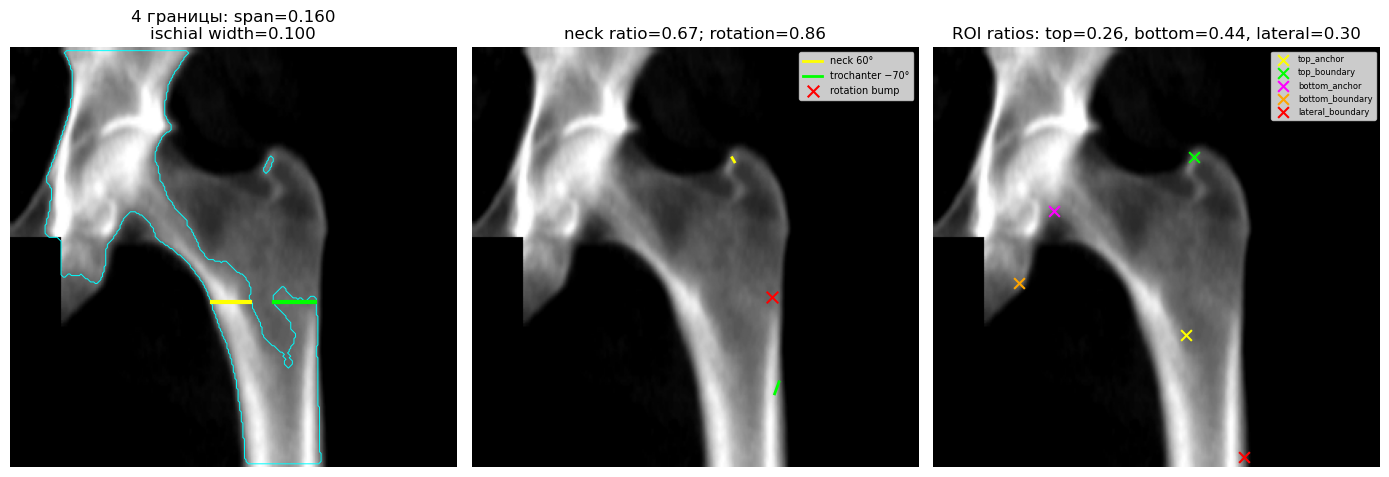

dicom_path                              C:\Users\Андрей\Desktop\Хакатон\Исследования\1...
side                                                                                 LEFT
mirrored_to_canonical                                                               False
bone_mask_area_fraction                                                          0.197583
four_boundary_row_fraction                                                       0.319392
four_boundary_longest_span_ratio                                                 0.159696
ischial_width_ratio                                                                   0.1
ischial_gap_ratio                                                                0.067857
femur_width_ratio                                                                0.064286
neck_min_width_px                                                                     4.0
neck_narrowing_ratio                                                             0.666667
neck_adjac

In [17]:
hip_candidates = representatives.loc[
    representatives["target_anatomy"].isin(["LEG_LEFT", "LEG_RIGHT"])
]
if len(hip_candidates):
    hip_example = hip_candidates.iloc[0]
    show_hip_diagnostics(
        hip_example["dicom_path"],
        "LEFT" if hip_example["target_anatomy"] == "LEG_LEFT" else "RIGHT",
    )
else:
    print("Не найден пример бедра")

# Опциональная проверка устойчивости маски и угловых срезов.
# Углы 60° и −70° остаются в сетке как центральные значения из задания.
RUN_HIP_GEOMETRY_SWEEP = False
if RUN_HIP_GEOMETRY_SWEEP and len(hip_candidates):
    geometry_grid = {
        "bone_quantile": [0.50, 0.56, 0.62, 0.68],
        "neck_angle_deg": [55.0, 60.0, 65.0],
        "trochanter_angle_deg": [-75.0, -70.0, -65.0],
    }
    geometry_cases = hip_candidates.sample(
        n=min(16, len(hip_candidates)), random_state=RANDOM_SEED
    )
    geometry_rows = []
    for variant_id, variant in enumerate(ParameterGrid(geometry_grid)):
        extracted = []
        for row in geometry_cases.itertuples(index=False):
            side = "LEFT" if row.target_anatomy == "LEG_LEFT" else "RIGHT"
            try:
                extracted.append(extract_hip_features(
                    row.dicom_path, side, params=variant
                ))
            except Exception:
                pass
        table = pd.DataFrame(extracted)
        if table.empty:
            continue
        geometry_rows.append({
            "variant_id": variant_id,
            **variant,
            "success_rate": len(table) / len(geometry_cases),
            "four_boundary_available": table["ischial_width_ratio"].notna().mean(),
            "neck_available": table["neck_narrowing_ratio"].notna().mean(),
            "trochanter_available": table["trochanter_narrowing_ratio"].notna().mean(),
            "roi_available": table["roi_top_margin_ratio"].notna().mean(),
            "median_neck_narrowing_ratio": table["neck_narrowing_ratio"].median(),
            "median_rotation_prominence_ratio": table["rotation_prominence_ratio"].median(),
        })
    geometry_sweep = pd.DataFrame(geometry_rows)
    geometry_sweep["availability_score"] = geometry_sweep[[
        "success_rate", "four_boundary_available", "neck_available",
        "trochanter_available", "roi_available",
    ]].mean(axis=1)
    display(geometry_sweep.sort_values("availability_score", ascending=False).head(20))


### Пакетное извлечение признаков бедра

Правые и левые изображения объединяются в одну таблицу после зеркального приведения.
Таргеты выбираются из соответствующей стороны Excel.


In [18]:
hip_cache = OUTPUT_DIR / "hip_features.csv"
hip_source = representatives.loc[
    representatives["target_anatomy"].isin(["LEG_LEFT", "LEG_RIGHT"])
].copy()

if hip_cache.exists() and not FORCE_RECOMPUTE:
    hip_features = pd.read_csv(hip_cache, low_memory=False)
    print("Загружен кэш:", hip_cache)
else:
    rows = []
    for row in tqdm(hip_source.itertuples(index=False), total=len(hip_source), desc="Hip features"):
        is_left = row.target_anatomy == "LEG_LEFT"
        side = "LEFT" if is_left else "RIGHT"
        position_target = getattr(
            row,
            "left_hip_position_rotation" if is_left else "right_hip_position_rotation",
            np.nan,
        )
        roi_target = getattr(row, "left_hip_roi" if is_left else "right_hip_roi", np.nan)
        base = {
            "source_row_id": row.source_row_id,
            "selection_study": row.selection_study,
            "task_study": row.task_study,
            "dicom_group": row.dicom_group,
            "dicom_path": str(row.dicom_path),
            "target_anatomy": row.target_anatomy,
            "side": side,
            "hip_position_rotation": position_target,
            "hip_roi": roi_target,
            "metal_target": row.metal_target,
        }
        try:
            features = extract_hip_features(row.dicom_path, side)
            rows.append({**base, **features, "processing_status": "Success"})
        except Exception as exc:
            rows.append({**base, "processing_status": "Failure",
                         "error_type": type(exc).__name__, "error_message": str(exc)})
    hip_features = pd.DataFrame(rows)
    hip_features.to_csv(hip_cache, index=False, encoding="utf-8-sig")
    print("Сохранено:", hip_cache)

display(pd.DataFrame({"value": {
    "cases": len(hip_features),
    "success": int(hip_features["processing_status"].eq("Success").sum()),
    "position_targets": int(pd.to_numeric(hip_features["hip_position_rotation"], errors="coerce").isin([0, 1]).sum()),
    "roi_targets": int(pd.to_numeric(hip_features["hip_roi"], errors="coerce").isin([0, 1]).sum()),
    "pixel_spacing_available": int(pd.to_numeric(hip_features["roi_top_margin_mm"], errors="coerce").notna().sum()),
}}))
display(hip_features.head())


Hip features:   0%|          | 0/152 [00:00<?, ?it/s]

Сохранено: C:\Users\Андрей\Desktop\Хакатон\prototype_output\target_tuning\hip_features.csv


,value
cases,152
success,152
position_targets,149
roi_targets,149
pixel_spacing_available,0


,source_row_id,selection_study,task_study,dicom_group,dicom_path,target_anatomy,side,hip_position_rotation,hip_roi,metal_target,...,roi_top_margin_px,roi_bottom_margin_px,roi_lateral_margin_px,roi_top_margin_ratio,roi_bottom_margin_ratio,roi_lateral_margin_ratio,roi_top_margin_mm,roi_bottom_margin_mm,roi_lateral_margin_mm,processing_status
0,2,1.2.840.113619.2.110.512719.20250403090444,1.2.840.113619.2.110.512719.20250403090444,1.2.840.113619.2.110.512719.20250403090444,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,LEG_LEFT,LEFT,1.0,0.0,0.0,...,68.0,115.0,85.0,0.258555,0.437262,0.303571,NaN,NaN,NaN,Success
1,1,1.2.840.113619.2.110.512719.20250403090444,1.2.840.113619.2.110.512719.20250403090444,1.2.840.113619.2.110.512719.20250403090444,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,LEG_RIGHT,RIGHT,0.0,0.0,0.0,...,64.0,91.0,68.0,0.272340,0.387234,0.242857,NaN,NaN,NaN,Success
2,8,1.2.840.113619.2.110.512719.20250403092052,1.2.840.113619.2.110.512719.20250403092052,1.2.840.113619.2.110.512719.20250403092052,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,LEG_LEFT,LEFT,0.0,0.0,0.0,...,71.0,187.0,50.0,0.269962,0.711027,0.178571,NaN,NaN,NaN,Success
3,6,1.2.840.113619.2.110.512719.20250403092052,1.2.840.113619.2.110.512719.20250403092052,1.2.840.113619.2.110.512719.20250403092052,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,LEG_RIGHT,RIGHT,0.0,0.0,0.0,...,68.0,115.0,90.0,0.289362,0.489362,0.321429,NaN,NaN,NaN,Success
4,12,1.2.840.113619.2.110.512719.20250407113211,1.2.840.113619.2.110.512719.20250407113211,1.2.840.113619.2.110.512719.20250407113211,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,LEG_LEFT,LEFT,1.0,0.0,0.0,...,70.0,125.0,71.0,0.266160,0.475285,0.253571,NaN,NaN,NaN,Success


## 9. Таргет 5: позиционирование и ротация бедра

Ручное правило объединяет четыре условия:

1. вертикальный интервал строк с четырьмя границами достаточно длинный;
2. ширина левой пары границ, соответствующей седалищной кости, не слишком мала и не
   слишком велика;
3. минимальное сечение шейки под 60° окружено утолщениями;
4. выступ малого вертела в координатах 60° не превышает порог.

Признаки большого вертела под −70° выводятся для анализа и дерева решений. Они не входят
в первое ручное правило, пока по ним не будет подтверждена устойчивая граница классов.


In [19]:
def hip_position_rule(frame, params):
    columns = [
        "four_boundary_longest_span_ratio", "ischial_width_ratio",
        "neck_adjacent_thickening_ratio", "rotation_prominence_ratio",
    ]
    values = frame[columns].apply(pd.to_numeric, errors="coerce")
    available = values.notna().all(axis=1)
    correct = (
        values["four_boundary_longest_span_ratio"].between(
            params["four_boundary_span_min"], params["four_boundary_span_max"]
        )
        & values["ischial_width_ratio"].between(
            params["ischial_width_min"], params["ischial_width_max"]
        )
        & (values["neck_adjacent_thickening_ratio"] >= params["neck_thickening_min"])
        & (values["rotation_prominence_ratio"] <= params["rotation_prominence_max"])
    )
    prediction = pd.Series(np.nan, index=frame.index)
    prediction.loc[available] = (~correct.loc[available]).astype(int)
    return prediction


hip_position_grid = {
    "four_boundary_span_min": [0.04, 0.06, 0.08, 0.10],
    "four_boundary_span_max": [0.35, 0.45, 0.55],
    "ischial_width_min": [0.025, 0.04, 0.06],
    "ischial_width_max": [0.16, 0.20, 0.24],
    "neck_thickening_min": [1.02, 1.10, 1.20, 1.30],
    "rotation_prominence_max": [0.15, 0.25, 0.35, 0.45],
}
hip_position_search = grid_search_rule(
    hip_features, "hip_position_rotation", hip_position_rule, hip_position_grid
)
hip_position_oof, hip_position_choices = grouped_oof_grid_search(
    hip_features, "hip_position_rotation", "selection_study",
    hip_position_rule, hip_position_grid
)
show_grid_result(
    "Таргет 5: позиционирование/ротация, ручное правило",
    hip_position_search, hip_position_oof, hip_position_choices
)

hip_tree_features = [
    "four_boundary_longest_span_ratio", "ischial_width_ratio", "ischial_gap_ratio",
    "neck_narrowing_ratio", "neck_adjacent_thickening_ratio",
    "trochanter_narrowing_ratio", "trochanter_adjacent_thickening_ratio",
    "rotation_prominence_ratio",
]
if "hip_position_rotation" in hip_features:
    hip_tree_metrics, hip_tree, hip_tree_rules = fit_shallow_tree_oof(
        hip_features, "hip_position_rotation", hip_tree_features,
        "selection_study", max_depth=3
    )
    if hip_tree_metrics is not None:
        display(pd.DataFrame([{"evaluation": "shallow_tree_group_oof", **hip_tree_metrics}]))
        print(hip_tree_rules)
    else:
        print(hip_tree_rules)


Таргет 5: позиционирование/ротация, ручное правило


,four_boundary_span_max,four_boundary_span_min,ischial_width_max,ischial_width_min,neck_thickening_min,rotation_prominence_max,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,0.35,0.06,0.24,0.060,1.3,0.25,148,35,31,82,8,27,0.391892,0.771429,0.274336,0.247706,0.522882,0.375000,0.542169,0.532526
1,0.45,0.06,0.24,0.060,1.3,0.25,148,35,31,82,8,27,0.391892,0.771429,0.274336,0.247706,0.522882,0.375000,0.542169,0.532526
2,0.55,0.06,0.24,0.060,1.3,0.25,148,35,31,82,8,27,0.391892,0.771429,0.274336,0.247706,0.522882,0.375000,0.542169,0.532526
3,0.35,0.06,0.16,0.060,1.3,0.25,148,35,30,83,8,27,0.385135,0.771429,0.265487,0.245455,0.518458,0.372414,0.540000,0.529229
4,0.35,0.06,0.20,0.060,1.3,0.25,148,35,30,83,8,27,0.385135,0.771429,0.265487,0.245455,0.518458,0.372414,0.540000,0.529229
5,0.35,0.08,0.16,0.025,1.3,0.25,148,35,30,83,8,27,0.385135,0.771429,0.265487,0.245455,0.518458,0.372414,0.540000,0.529229
6,0.35,0.08,0.16,0.040,1.3,0.25,148,35,30,83,8,27,0.385135,0.771429,0.265487,0.245455,0.518458,0.372414,0.540000,0.529229
7,0.35,0.08,0.16,0.060,1.3,0.25,148,35,30,83,8,27,0.385135,0.771429,0.265487,0.245455,0.518458,0.372414,0.540000,0.529229
8,0.35,0.08,0.20,0.025,1.3,0.25,148,35,30,83,8,27,0.385135,0.771429,0.265487,0.245455,0.518458,0.372414,0.540000,0.529229
9,0.35,0.08,0.20,0.040,1.3,0.25,148,35,30,83,8,27,0.385135,0.771429,0.265487,0.245455,0.518458,0.372414,0.540000,0.529229


,evaluation,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,group_oof,148,35,30,83,12,23,0.358108,0.657143,0.265487,0.216981,0.461315,0.326241,0.46748,0.464397


,fold,test_n,four_boundary_span_min,four_boundary_span_max,ischial_width_min,ischial_width_max,neck_thickening_min,rotation_prominence_max
0,0,28,0.04,0.35,0.060,0.24,1.30,0.35
1,1,31,0.06,0.35,0.060,0.24,1.02,0.25
2,2,30,0.06,0.35,0.060,0.24,1.30,0.25
3,3,31,0.06,0.35,0.060,0.24,1.30,0.25
4,4,28,0.06,0.35,0.025,0.16,1.30,0.25


,evaluation,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,shallow_tree_group_oof,147,35,43,69,20,15,0.394558,0.428571,0.383929,0.178571,0.40625,0.252101,0.334821,0.370536


|--- trochanter_narrowing_ratio <= 0.69
|   |--- four_boundary_longest_span_ratio <= 0.19
|   |   |--- neck_narrowing_ratio <= 0.44
|   |   |   |--- class: 1
|   |   |--- neck_narrowing_ratio >  0.44
|   |   |   |--- class: 0
|   |--- four_boundary_longest_span_ratio >  0.19
|   |   |--- four_boundary_longest_span_ratio <= 0.22
|   |   |   |--- class: 0
|   |   |--- four_boundary_longest_span_ratio >  0.22
|   |   |   |--- class: 1
|--- trochanter_narrowing_ratio >  0.69
|   |--- rotation_prominence_ratio <= 1.54
|   |   |--- class: 0
|   |--- rotation_prominence_ratio >  1.54
|   |   |--- class: 0



## 10. Таргет 6: корректность области интересов

При наличии `PixelSpacing` используется фиксированное правило из задания:

- сверху ≥ 30 мм;
- снизу ≥ 30 мм;
- латерально ≥ 20 мм.

Если физический размер пикселя отсутствует, сантиметры не подменяются выдуманным
масштабом. Для исследовательского сравнения отдельно подбираются безразмерные отношения
к высоте и ширине кадра. Такой fallback нельзя переносить между приборами без валидации.


In [20]:
def hip_roi_mm_rule(frame, params):
    columns = ["roi_top_margin_mm", "roi_bottom_margin_mm", "roi_lateral_margin_mm"]
    values = frame[columns].apply(pd.to_numeric, errors="coerce")
    available = values.notna().all(axis=1)
    correct = (
        (values["roi_top_margin_mm"] >= params["top_mm"])
        & (values["roi_bottom_margin_mm"] >= params["bottom_mm"])
        & (values["roi_lateral_margin_mm"] >= params["lateral_mm"])
    )
    prediction = pd.Series(np.nan, index=frame.index)
    prediction.loc[available] = (~correct.loc[available]).astype(int)
    return prediction


fixed_mm_grid = {"top_mm": [30.0], "bottom_mm": [30.0], "lateral_mm": [20.0]}
hip_roi_mm_result = grid_search_rule(hip_features, "hip_roi", hip_roi_mm_rule, fixed_mm_grid)
show_grid_result("Таргет 6: фиксированное правило в миллиметрах", hip_roi_mm_result)


def hip_roi_ratio_rule(frame, params):
    columns = ["roi_top_margin_ratio", "roi_bottom_margin_ratio", "roi_lateral_margin_ratio"]
    values = frame[columns].apply(pd.to_numeric, errors="coerce")
    available = values.notna().all(axis=1)
    correct = (
        (values["roi_top_margin_ratio"] >= params["top_ratio"])
        & (values["roi_bottom_margin_ratio"] >= params["bottom_ratio"])
        & (values["roi_lateral_margin_ratio"] >= params["lateral_ratio"])
    )
    prediction = pd.Series(np.nan, index=frame.index)
    prediction.loc[available] = (~correct.loc[available]).astype(int)
    return prediction


# Начальные диапазоны согласованы со схемой, но подбираются по исходным DICOM, не по PNG.
hip_roi_ratio_grid = {
    "top_ratio": [0.06, 0.08, 0.10, 0.12, 0.15, 0.18],
    "bottom_ratio": [0.06, 0.08, 0.10, 0.12, 0.15, 0.18],
    "lateral_ratio": [0.04, 0.06, 0.08, 0.10, 0.12, 0.15],
}
hip_roi_ratio_search = grid_search_rule(
    hip_features, "hip_roi", hip_roi_ratio_rule, hip_roi_ratio_grid
)
hip_roi_ratio_oof, hip_roi_ratio_choices = grouped_oof_grid_search(
    hip_features, "hip_roi", "selection_study",
    hip_roi_ratio_rule, hip_roi_ratio_grid
)
show_grid_result(
    "Таргет 6: экспериментальный fallback по отношениям",
    hip_roi_ratio_search, hip_roi_ratio_oof, hip_roi_ratio_choices
)


Таргет 6: фиксированное правило в миллиметрах
Нет пар target/prediction для подбора.
Таргет 6: экспериментальный fallback по отношениям


,bottom_ratio,lateral_ratio,top_ratio,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,0.06,0.04,0.06,149,6,121,22,6,0,0.812081,0.0,0.846154,0.0,0.423077,0.0,0.0,0.211538
1,0.06,0.04,0.08,149,6,121,22,6,0,0.812081,0.0,0.846154,0.0,0.423077,0.0,0.0,0.211538
2,0.06,0.04,0.10,149,6,121,22,6,0,0.812081,0.0,0.846154,0.0,0.423077,0.0,0.0,0.211538
3,0.06,0.04,0.12,149,6,121,22,6,0,0.812081,0.0,0.846154,0.0,0.423077,0.0,0.0,0.211538
4,0.06,0.04,0.15,149,6,121,22,6,0,0.812081,0.0,0.846154,0.0,0.423077,0.0,0.0,0.211538
5,0.06,0.04,0.18,149,6,121,22,6,0,0.812081,0.0,0.846154,0.0,0.423077,0.0,0.0,0.211538
6,0.06,0.06,0.06,149,6,121,22,6,0,0.812081,0.0,0.846154,0.0,0.423077,0.0,0.0,0.211538
7,0.06,0.06,0.08,149,6,121,22,6,0,0.812081,0.0,0.846154,0.0,0.423077,0.0,0.0,0.211538
8,0.06,0.06,0.10,149,6,121,22,6,0,0.812081,0.0,0.846154,0.0,0.423077,0.0,0.0,0.211538
9,0.06,0.06,0.12,149,6,121,22,6,0,0.812081,0.0,0.846154,0.0,0.423077,0.0,0.0,0.211538


,evaluation,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,group_oof,149,6,121,22,6,0,0.812081,0.0,0.846154,0.0,0.423077,0.0,0.0,0.211538


,fold,test_n,top_ratio,bottom_ratio,lateral_ratio
0,0,30,0.06,0.06,0.04
1,1,30,0.06,0.06,0.04
2,2,30,0.06,0.06,0.04
3,3,30,0.06,0.06,0.04
4,4,29,0.06,0.06,0.04


## 11. Таргет 7: металл

Основной признак — `metal_score` сохранённого CNN. Он не является калиброванной
вероятностью. Дополнительно рассчитываются простые признаки экстремально ярких связных
компонент, чтобы находить случаи, которые CNN мог пропустить.

В текущих данных положительных изображений очень мало. Group cross-validation может быть
невозможна, если металл относится менее чем к двум независимым исследованиям. В таком
случае notebook показывает только описательную оценку и не выдаёт порог за надёжный.
Применение CNN к позвоночнику помечено как out-of-distribution, поскольку metal-head
обучался на снимках бедра.


Metal features:   0%|          | 0/332 [00:00<?, ?it/s]

Сохранено: C:\Users\Андрей\Desktop\Хакатон\prototype_output\target_tuning\metal_features.csv


,images
metal_target,
0.0,328
1.0,4


Независимых положительных групп: 2


,source_row_id,selection_study,task_study,dicom_group,dicom_path,target_anatomy,metal_target,metal_score,metal_checkpoint_threshold,metal_extreme_fraction,metal_largest_component_fraction,metal_peak_contrast,processing_status
52,83,2.25.12798473087614376830819854616447908612,2.25.12798473087614376830819854616447908612,2.25.12798473087614376830819854616447908612,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_RIGHT,1.0,0.999981,0.000417,0.116527,0.113311,0.000000,Success
51,82,2.25.12798473087614376830819854616447908612,2.25.12798473087614376830819854616447908612,2.25.12798473087614376830819854616447908612,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,1.0,0.999765,0.000417,0.106015,0.102445,0.000000,Success
26,40,2.25.11175860580562939441493697221497597640,2.25.11175860580562939441493697221497597640,2.25.11175860580562939441493697221497597640,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_RIGHT,1.0,0.000395,0.000417,0.016441,0.004772,0.126374,Success
29,45,2.25.11175860580562939441493697221497597640,2.25.11175860580562939441493697221497597640,2.25.11175860580562939441493697221497597640,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_RIGHT,1.0,0.000395,0.000417,0.016441,0.004772,0.126374,Success
251,376,2.25.272690031744216183651627058502316132741,2.25.272690031744216183651627058502316132741,2.25.272690031744216183651627058502316132741,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,0.0,0.000361,0.000417,0.006529,0.004252,0.131035,Success
252,378,2.25.272690031744216183651627058502316132741,2.25.272690031744216183651627058502316132741,2.25.272690031744216183651627058502316132741,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,0.0,0.000361,0.000417,0.006529,0.004252,0.131035,Success
246,370,2.25.272690031744216183651627058502316132741,2.25.272690031744216183651627058502316132741,2.25.272690031744216183651627058502316132741,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,0.0,0.000361,0.000417,0.006529,0.004252,0.131035,Success
247,371,2.25.272690031744216183651627058502316132741,2.25.272690031744216183651627058502316132741,2.25.272690031744216183651627058502316132741,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,0.0,0.000361,0.000417,0.006529,0.004252,0.131035,Success
283,425,2.25.339027809107632348165171236474821772940,2.25.339027809107632348165171236474821772940,2.25.339027809107632348165171236474821772940,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,0.0,0.000330,0.000417,0.006106,0.006106,0.226277,Success
282,424,2.25.339027809107632348165171236474821772940,2.25.339027809107632348165171236474821772940,2.25.339027809107632348165171236474821772940,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,LEG_LEFT,0.0,0.000330,0.000417,0.006106,0.006106,0.226277,Success


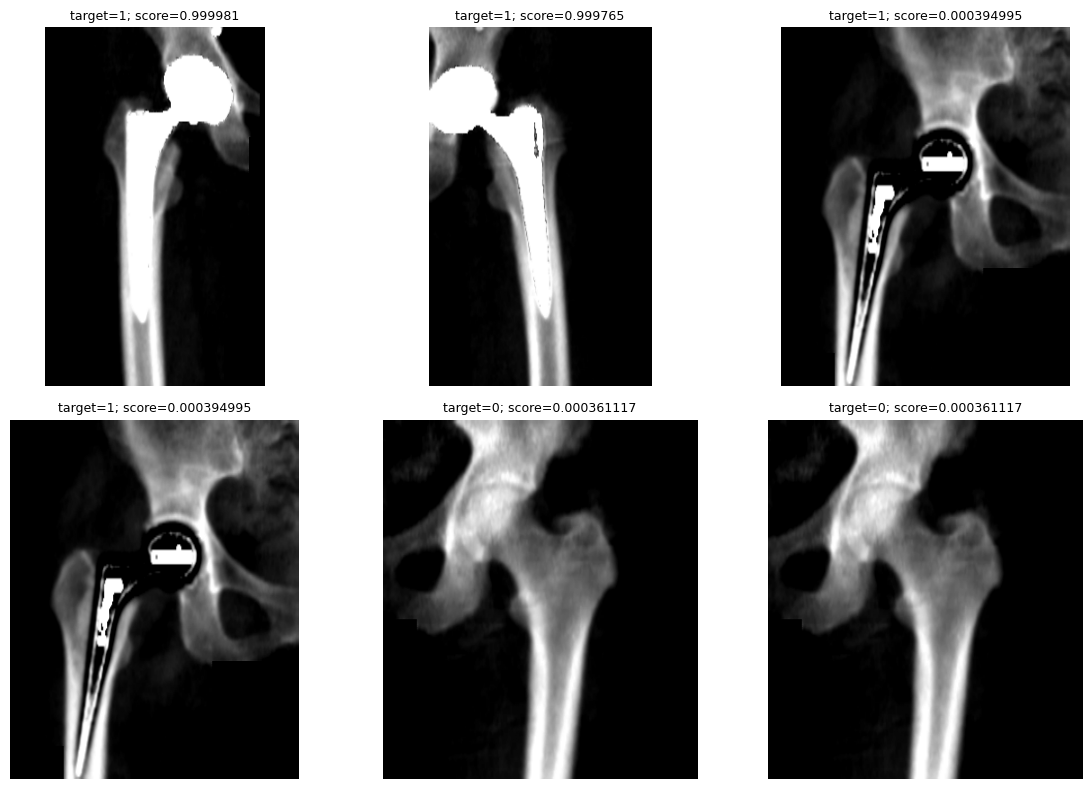

In [21]:
def metal_segmentation_features(image):
    positive = image[image > 0]
    if len(positive) == 0:
        return {
            "metal_extreme_fraction": np.nan,
            "metal_largest_component_fraction": np.nan,
            "metal_peak_contrast": np.nan,
        }
    q50, q95, q995 = np.quantile(positive, [0.50, 0.95, 0.995])
    extreme = image >= q995
    extreme = binary_opening(extreme, iterations=1)
    labeled, count = ndi_label(extreme)
    sizes = np.bincount(labeled.ravel()) if count else np.array([0])
    largest = float(sizes[1:].max() / image.size) if count else 0.0
    peak_contrast = float((image.max() - q95) / max(q95 - q50, 1e-6))
    return {
        "metal_extreme_fraction": float(extreme.mean()),
        "metal_largest_component_fraction": largest,
        "metal_peak_contrast": peak_contrast,
    }


metal_cache = OUTPUT_DIR / "metal_features.csv"
metal_source = images.loc[images["metal_target"].isin([0, 1])].copy()
if metal_cache.exists() and not FORCE_RECOMPUTE:
    metal_features = pd.read_csv(metal_cache, low_memory=False)
    print("Загружен кэш:", metal_cache)
else:
    rows = []
    for row in tqdm(metal_source.itertuples(index=False), total=len(metal_source), desc="Metal features"):
        base = {
            "source_row_id": row.source_row_id,
            "selection_study": row.selection_study,
            "task_study": row.task_study,
            "dicom_group": row.dicom_group,
            "dicom_path": str(row.dicom_path),
            "target_anatomy": row.target_anatomy,
            "metal_target": row.metal_target,
        }
        try:
            _, image, _, _ = load_image(row.dicom_path)
            cnn = pipeline.predict_metal(image)
            rows.append({
                **base,
                "metal_score": cnn["metal_score"],
                "metal_checkpoint_threshold": cnn["metal_threshold"],
                **metal_segmentation_features(image),
                "processing_status": "Success",
            })
        except Exception as exc:
            rows.append({**base, "processing_status": "Failure",
                         "error_type": type(exc).__name__, "error_message": str(exc)})
    metal_features = pd.DataFrame(rows)
    metal_features.to_csv(metal_cache, index=False, encoding="utf-8-sig")
    print("Сохранено:", metal_cache)

display(metal_features["metal_target"].value_counts(dropna=False).rename("images").to_frame())
print(
    "Независимых положительных групп:",
    metal_features.loc[metal_features["metal_target"].eq(1), "selection_study"].nunique(),
)
display(metal_features.sort_values("metal_score", ascending=False).head(30))

top_metal_cases = metal_features.sort_values("metal_score", ascending=False).head(6)
if len(top_metal_cases):
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for axis, row in zip(axes.ravel(), top_metal_cases.itertuples(index=False)):
        _, image, _, _ = load_image(row.dicom_path)
        axis.imshow(image, cmap="gray")
        axis.set_title(
            f"target={int(row.metal_target)}; score={row.metal_score:.6g}",
            fontsize=9,
        )
        axis.axis("off")
    for axis in axes.ravel()[len(top_metal_cases):]:
        axis.axis("off")
    plt.tight_layout()
    plt.show()


In [22]:
def metal_threshold_rule(frame, params):
    values = pd.to_numeric(frame["metal_score"], errors="coerce")
    prediction = pd.Series(np.nan, index=frame.index)
    prediction.loc[values.notna()] = (values.loc[values.notna()] >= params["threshold"]).astype(int)
    return prediction


score_values = pd.to_numeric(metal_features.get("metal_score", pd.Series(dtype=float)), errors="coerce").dropna()
metal_thresholds = set(quantile_grid(score_values, (0.50, 0.70, 0.85, 0.92, 0.96, 0.98, 0.99, 0.995)))
metal_thresholds.add(float(pipeline.metal_threshold))
positive_scores = pd.to_numeric(
    metal_features.loc[metal_features["metal_target"].eq(1), "metal_score"], errors="coerce"
).dropna()
metal_thresholds.update(float(value) for value in positive_scores)
metal_threshold_grid = {"threshold": sorted(value for value in metal_thresholds if 0 < value < 1)}

metal_search = grid_search_rule(
    metal_features, "metal_target", metal_threshold_rule, metal_threshold_grid
)
metal_oof, metal_choices = grouped_oof_grid_search(
    metal_features, "metal_target", "selection_study",
    metal_threshold_rule, metal_threshold_grid
)
show_grid_result("Таргет 7: metal-head", metal_search, metal_oof, metal_choices)

metal_tree_features = [
    "metal_score", "metal_extreme_fraction",
    "metal_largest_component_fraction", "metal_peak_contrast",
]
metal_tree_metrics, metal_tree, metal_tree_rules = fit_shallow_tree_oof(
    metal_features, "metal_target", metal_tree_features,
    "selection_study", max_depth=2
)
if metal_tree_metrics is not None:
    display(pd.DataFrame([{"evaluation": "shallow_tree_group_oof", **metal_tree_metrics}]))
    print(metal_tree_rules)
else:
    print(metal_tree_rules)


Таргет 7: metal-head


,threshold,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,0.000384,332,4,328,0,0,4,1.000000,1.00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.000395,332,4,328,0,0,4,1.000000,1.00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.000361,332,4,324,4,0,4,0.987952,1.00,0.987805,0.500000,0.993902,0.666667,0.833333,0.913618
3,0.000278,332,4,318,10,0,4,0.969880,1.00,0.969512,0.285714,0.984756,0.444444,0.666667,0.825711
4,0.000136,332,4,305,23,0,4,0.930723,1.00,0.929878,0.148148,0.964939,0.258065,0.465116,0.715028
5,0.000417,332,4,328,0,2,2,0.993976,0.50,1.000000,1.000000,0.750000,0.666667,0.555556,0.652778
6,0.345178,332,4,328,0,2,2,0.993976,0.50,1.000000,1.000000,0.750000,0.666667,0.555556,0.652778
7,0.999765,332,4,328,0,2,2,0.993976,0.50,1.000000,1.000000,0.750000,0.666667,0.555556,0.652778
8,0.000085,332,4,282,46,0,4,0.861446,1.00,0.859756,0.080000,0.929878,0.148148,0.303030,0.616454
9,0.000042,332,4,231,97,0,4,0.707831,1.00,0.704268,0.039604,0.852134,0.076190,0.170940,0.511537


,evaluation,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,group_oof,332,4,318,10,0,4,0.96988,1.0,0.969512,0.285714,0.984756,0.444444,0.666667,0.825711


,fold,test_n,threshold
0,0,165,0.000278
1,1,167,0.000384


,evaluation,n,violations,tn,fp,fn,tp,accuracy,sensitivity,specificity,precision,balanced_accuracy,f1,f2,objective
0,shallow_tree_group_oof,332,4,278,50,2,2,0.843373,0.5,0.847561,0.038462,0.67378,0.071429,0.147059,0.41042


|--- metal_score <= 0.00
|   |--- class: 0
|--- metal_score >  0.00
|   |--- class: 1



### Экспериментальный поиск металла на позвоночнике

Здесь CNN используется только для сортировки кандидатов на ручной просмотр. Без
позвоночной разметки `metal=0/1` нельзя вычислить sensitivity, подобрать порог или заявить
работоспособность модели на этой анатомии.


In [23]:
spine_metal_candidates_cache = OUTPUT_DIR / "spine_metal_candidates.csv"
if spine_metal_candidates_cache.exists() and not FORCE_RECOMPUTE:
    spine_metal_candidates = pd.read_csv(spine_metal_candidates_cache, low_memory=False)
else:
    candidate_rows = []
    for row in tqdm(spine_source.itertuples(index=False), total=len(spine_source), desc="Spine metal candidates"):
        try:
            _, image, _, _ = load_image(row.dicom_path)
            score = pipeline.predict_metal(image)["metal_score"]
            candidate_rows.append({
                "selection_study": row.selection_study,
                "dicom_path": str(row.dicom_path),
                "metal_cnn_score_ood": score,
                **metal_segmentation_features(image),
            })
        except Exception as exc:
            candidate_rows.append({"selection_study": row.selection_study,
                                   "dicom_path": str(row.dicom_path),
                                   "error_message": str(exc)})
    spine_metal_candidates = pd.DataFrame(candidate_rows)
    spine_metal_candidates.to_csv(spine_metal_candidates_cache, index=False, encoding="utf-8-sig")
display(spine_metal_candidates.sort_values("metal_cnn_score_ood", ascending=False).head(20))


Spine metal candidates:   0%|          | 0/99 [00:00<?, ?it/s]

,selection_study,dicom_path,metal_cnn_score_ood,metal_extreme_fraction,metal_largest_component_fraction,metal_peak_contrast
5,2.25.102965897799404973225419898683246248872,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.028030,0.013206,0.008561,0.033113
65,2.25.220866240977467582196609708837940253840,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.025042,0.006351,0.001725,0.275000
16,2.25.125521310320333648427417313254965624364,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.021891,0.006096,0.001255,0.170543
44,2.25.165091430504580219034019815337441064349,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.020035,0.004948,0.001974,0.263889
82,2.25.340839477910528898406207279980417945,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.016174,0.005899,0.002576,0.243590
8,2.25.108537195937431169718850276671337677972,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.015536,0.005871,0.000980,0.253012
84,2.25.39068163399801173920284179500049527111,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.014378,0.004633,0.001782,0.263514
43,2.25.164566280810634620154538016595892212884,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.012057,0.005180,0.001974,0.187500
24,2.25.132083163398091874662674590622589534350,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.012007,0.004417,0.000760,0.250000
68,2.25.269648774413746842548908998641183395622,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,0.011852,0.006225,0.001714,0.214286


## 12. Итоговая таблица и сохранение параметров

`best_parameters.json` содержит лучшие параметры на полном наборе и OOF-метрики, если
group cross-validation была возможна. Для финального пайплайна следует использовать
параметры с устойчивым OOF-результатом и после визуального просмотра FP/FN.


In [24]:
def best_params(search, parameter_names):
    if search is None or search.empty:
        return None
    return {
        name: (search.iloc[0][name].item() if hasattr(search.iloc[0][name], "item") else search.iloc[0][name])
        for name in parameter_names
    }


def json_safe(value):
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, (np.integer, np.floating)):
        value = value.item()
    if isinstance(value, float) and not np.isfinite(value):
        return None
    return value


best_configuration = {
    "target_1_spine_coverage": {
        "best_full_data_params": best_params(coverage_search, list(coverage_grid)),
        "group_oof_metrics": coverage_oof,
        "segmentation_method": sorted(spine_features.get("iliac_method", pd.Series(dtype=str)).dropna().unique().tolist()),
    },
    "target_2_spine_alignment": {
        "best_full_data_params": best_params(alignment_search, list(alignment_grid)),
        "group_oof_metrics": alignment_oof,
    },
    "target_3_spine_artifacts": {
        "best_full_data_params": best_params(artifact_search, list(artifact_grid)) if 'artifact_search' in globals() else None,
        "group_oof_metrics": artifact_oof if 'artifact_oof' in globals() else None,
        "shallow_tree_group_oof": artifact_tree_metrics if 'artifact_tree_metrics' in globals() else None,
    },
    "target_4_scoliosis": {
        "best_full_data_params": best_params(scoliosis_search, list(scoliosis_grid)),
        "group_oof_metrics": scoliosis_oof,
        "target_source": "comment contains scoliosis",
    },
    "target_5_hip_position_rotation": {
        "best_full_data_params": best_params(hip_position_search, list(hip_position_grid)),
        "group_oof_metrics": hip_position_oof,
        "shallow_tree_group_oof": hip_tree_metrics if 'hip_tree_metrics' in globals() else None,
    },
    "target_6_hip_roi": {
        "fixed_mm_rule": {"top_mm": 30.0, "bottom_mm": 30.0, "lateral_mm": 20.0},
        "best_ratio_fallback_params": best_params(hip_roi_ratio_search, list(hip_roi_ratio_grid)),
        "group_oof_metrics": hip_roi_ratio_oof,
    },
    "target_7_metal": {
        "checkpoint_threshold": float(pipeline.metal_threshold),
        "best_full_data_threshold": best_params(metal_search, ["threshold"]),
        "group_oof_metrics": metal_oof,
        "positive_images": int(pd.to_numeric(metal_features["metal_target"], errors="coerce").eq(1).sum()),
        "positive_groups": int(metal_features.loc[metal_features["metal_target"].eq(1), "selection_study"].nunique()),
    },
}

summary_rows = []
for task, payload in best_configuration.items():
    oof = payload.get("group_oof_metrics") or {}
    summary_rows.append({
        "task": task,
        "oof_available": bool(oof),
        "oof_n": oof.get("n"),
        "oof_sensitivity": oof.get("sensitivity"),
        "oof_specificity": oof.get("specificity"),
        "oof_balanced_accuracy": oof.get("balanced_accuracy"),
        "best_parameters": json.dumps(json_safe(payload.get("best_full_data_params") or payload.get("best_ratio_fallback_params")), ensure_ascii=False),
    })
algorithm_summary = pd.DataFrame(summary_rows)
display(algorithm_summary)

configuration_path = OUTPUT_DIR / "best_parameters.json"
summary_path = OUTPUT_DIR / "algorithm_summary.csv"
configuration_path.write_text(
    json.dumps(json_safe(best_configuration), ensure_ascii=False, indent=2),
    encoding="utf-8",
)
algorithm_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
print("Параметры:", configuration_path)
print("Сводка:", summary_path)


,task,oof_available,oof_n,oof_sensitivity,oof_specificity,oof_balanced_accuracy,best_parameters
0,target_1_spine_coverage,True,99,0.833333,0.408602,0.620968,"{""separator_min"": 5.0, ""separator_max"": 6.0, ""..."
1,target_2_spine_alignment,True,99,0.500000,0.730337,0.615169,"{""method"": ""boundary"", ""max_deviation_deg"": 4.0}"
2,target_3_spine_artifacts,True,99,0.705882,0.621951,0.663917,"{""extra_component_max"": 0.00014549266247379435..."
3,target_4_scoliosis,True,99,0.785714,0.576471,0.681092,"{""method"": ""boundary"", ""angle_threshold_deg"": ..."
4,target_5_hip_position_rotation,True,148,0.657143,0.265487,0.461315,"{""four_boundary_span_min"": 0.06, ""four_boundar..."
5,target_6_hip_roi,True,149,0.000000,0.846154,0.423077,"{""top_ratio"": 0.06, ""bottom_ratio"": 0.06, ""lat..."
6,target_7_metal,True,332,1.000000,0.969512,0.984756,null


Параметры: C:\Users\Андрей\Desktop\Хакатон\prototype_output\target_tuning\best_parameters.json
Сводка: C:\Users\Андрей\Desktop\Хакатон\prototype_output\target_tuning\algorithm_summary.csv


## Порядок принятия алгоритма в основной пайплайн

Для каждого таргета:

1. просмотреть наложения landmarks минимум на норме, нарушении, FP и FN;
2. исключить алгоритмы, которые находят не ту анатомическую структуру, даже если их
   численная метрика случайно высока;
3. выбирать параметры по group-OOF, а не по метрике на полном наборе;
4. зафиксировать параметры и проверить их на отдельном test set;
5. только после этого перенести правило в `dxa_inference_pipeline.py`.

Особые ограничения текущего набора:

- generic SAM не обучен специально на DXA и требует проверки масок;
- без `PixelSpacing` критерии 3/3/2 см нельзя вычислить физически;
- таргет сколиоза извлечён из свободного комментария;
- metal-head имеет крайне мало положительных исследований;
- позвоночная разметка металла отсутствует или должна быть добавлена отдельно.
